# Qualitative Case Finder: BERT UltraCLIP vs BiomedCLIP

This standalone notebook finds examples where your **EchoCare + BioClinicalBERT UltraCLIP model** performs better than **BiomedCLIP** on label-prompt classification, then generates an OpenAI-CLIP-style qualitative plot: one ultrasound image with ranked label probabilities from both models.

Assumptions:
- Input folders and model paths are the same as `echocare-clip-bert-apr24.ipynb`.
- The evaluation split comes from the saved `test_df.csv`.
- Dataset CSVs may use inconsistent columns (`label`, `Label`, `caption`, `text_caption`, `annotation`, etc.), so labels are recovered robustly.


In [1]:
# Install dependencies if needed. On Kaggle, you may already have some of these.
!pip install -q monai transformers open_clip_torch einops pandas pillow matplotlib tqdm scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 53.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 69.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.9 MB/s eta 0:00:00


In [2]:
import os
import re
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

from monai.networks.nets.swin_unetr import SwinTransformer
from transformers import AutoModel, AutoTokenizer
from open_clip import create_model_from_pretrained, get_tokenizer

# Device
if torch.cuda.is_available():
    device = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print('Using device:', device)

2026-04-28 19:58:27.688172: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777406307.896023      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777406307.963839      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777406308.425171      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777406308.425220      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777406308.425223      57 computation_placer.cc:177] computation placer alr

Using device: cuda


In [3]:
config = {
    # Data / split paths
    'prepared_data_root': '/kaggle/input/datasets/yiyangzhangyoung/bmi702-preprocessed/prepared_data',
    'reference_test_csv': '/kaggle/input/datasets/yiyangzhangyoung/bmi702-preprocessed/test_df.csv',
    'old_path_root': '/home/zhuoyangl/tryout/bmi702/data/data',
    'new_path_root': '/kaggle/input/datasets/yiyangzhangyoung/bmi702-preprocessed/prepared_data/prepared_data',

    # BERT UltraCLIP trained models
    'saved_model_dir': '/kaggle/input/models/yiyangzhangyoung/ultraclip/transformers/default/5/EchoCare-CLIP-BERT-Apr24',
    'trained_models': {
        'MLP heads only (BERT)': 'echocare_bert_mlp_heads_only.pt',
        'MLP + image encoder (BERT)': 'echocare_bert_mlp_and_image_encoder.pt',
        'MLP + text encoder (BERT)': 'echocare_bert_mlp_and_text_encoder.pt',
        'MLP + image + text encoder (BERT)': 'echocare_bert_mlp_image_and_text_encoder.pt',
    },

    # Choose the trained model used for qualitative comparison
    'bert_model_name_for_qual': 'MLP + image + text encoder (BERT)',

    # Model settings: must match training
    'feature_size': 128,
    'in_channels': 3,
    'image_size': 256,
    'projection_dim': 256,
    'text_model_name': 'emilyalsentzer/Bio_ClinicalBERT',
    'clip_model_name': 'emilyalsentzer/Bio_ClinicalBERT',  # backward-compatible alias
    'max_seq_len': 128,
    'img_mean': [0.190874, 0.192657, 0.196386],
    'img_std': [0.200044, 0.20141, 0.204307],

    # BiomedCLIP baseline
    'biomedclip_model_name': 'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224',

    # Evaluation settings
    'batch_size': 32,
    'num_workers': 0,
}
config

{'prepared_data_root': '/kaggle/input/datasets/yiyangzhangyoung/bmi702-preprocessed/prepared_data',
 'reference_test_csv': '/kaggle/input/datasets/yiyangzhangyoung/bmi702-preprocessed/test_df.csv',
 'old_path_root': '/home/zhuoyangl/tryout/bmi702/data/data',
 'new_path_root': '/kaggle/input/datasets/yiyangzhangyoung/bmi702-preprocessed/prepared_data/prepared_data',
 'saved_model_dir': '/kaggle/input/models/yiyangzhangyoung/ultraclip/transformers/default/5/EchoCare-CLIP-BERT-Apr24',
 'trained_models': {'MLP heads only (BERT)': 'echocare_bert_mlp_heads_only.pt',
  'MLP + image encoder (BERT)': 'echocare_bert_mlp_and_image_encoder.pt',
  'MLP + text encoder (BERT)': 'echocare_bert_mlp_and_text_encoder.pt',
  'MLP + image + text encoder (BERT)': 'echocare_bert_mlp_image_and_text_encoder.pt'},
 'bert_model_name_for_qual': 'MLP + image + text encoder (BERT)',
 'feature_size': 128,
 'in_channels': 3,
 'image_size': 256,
 'projection_dim': 256,
 'text_model_name': 'emilyalsentzer/Bio_ClinicalB

In [4]:
# -----------------------------
# Path, label, and prompt helpers
# -----------------------------
def remap_path_to_kaggle(path):
    return str(path).replace(config['old_path_root'], config['new_path_root'])

def norm_rel_path(p):
    return str(p).replace('\\', '/').strip()

def normalize_filename(p):
    return Path(str(p)).name

def clean_label(x):
    if pd.isna(x):
        return pd.NA
    x = str(x).strip().lower()
    if x in ['', 'nan', 'none', 'unknown', 'not available']:
        return pd.NA
    return x

def infer_label_from_text(text):
    if pd.isna(text):
        return pd.NA
    s = str(text).lower()
    if re.search(r'\bmalignant\b|\bcarcinoma\b|\bcancer\b', s):
        return 'malignant'
    if re.search(r'\bbenign\b|\bfibroadenoma\b', s):
        return 'benign'
    if re.search(r'\bnormal\b|no clear space-occupying lesions|no obvious abnormal', s):
        return 'normal'
    if re.search(r'\bcovid\b', s):
        return 'covid'
    if re.search(r'\bpneumonia\b', s):
        return 'pneumonia'
    return pd.NA

def standardize_label(raw):
    lab = clean_label(raw)
    if pd.isna(lab):
        return pd.NA
    s = str(lab).lower()
    if 'malignant' in s or 'carcinoma' in s or 'cancer' in s:
        return 'malignant'
    if 'benign' in s or 'fibroadenoma' in s:
        return 'benign'
    if 'normal' in s:
        return 'normal'
    if 'covid' in s:
        return 'covid'
    if 'pneumonia' in s:
        return 'pneumonia'
    return s

def infer_organ_from_dataset(dataset_name: str) -> str:
    s = str(dataset_name).strip().lower()
    if ('busi' in s) or ('breast' in s) or ('bus-lesion' in s):
        return 'breast'
    if 'lung' in s:
        return 'lung'
    if ('auli' in s) or ('liver' in s):
        return 'liver'
    if ('auitd' in s) or ('thyroid' in s):
        return 'thyroid'
    if ('artery' in s) or ('carotid' in s):
        return 'carotid artery'
    return 'ultrasound'

def build_label_prompt_for_dataset(label, dataset_name):
    label = str(label).strip().lower()
    organ = infer_organ_from_dataset(dataset_name)
    if organ == 'ultrasound':
        return f'An ultrasound image with {label} findings.'
    return f'An ultrasound image of {organ} with {label} findings.'

In [5]:
# -----------------------------
# Load saved test split and recover labels from prepared dataset CSVs
# -----------------------------

def load_reference_test_split(csv_path):
    df = pd.read_csv(csv_path)
    df['image_path'] = df['image_path'].apply(remap_path_to_kaggle)
    if 'caption' not in df.columns and 'text_caption' in df.columns:
        df = df.rename(columns={'text_caption': 'caption'})
    if 'dataset' not in df.columns:
        df['dataset'] = 'unknown'
    df['filename'] = df['image_path'].apply(normalize_filename)
    df['rel_tail_2'] = df['image_path'].apply(lambda p: '/'.join(Path(str(p)).parts[-2:]))
    return df

test_df = load_reference_test_split(config['reference_test_csv'])

prepared_root = Path(config['new_path_root'])
caption_csvs = list(prepared_root.rglob('*.csv'))
print('Found caption CSVs:', len(caption_csvs))
for p in caption_csvs:
    print(' ', p)

lookup_rows = []
for csv_file in caption_csvs:
    try:
        tmp = pd.read_csv(csv_file)
        tmp.columns = [c.strip() for c in tmp.columns]

        image_col = None
        for candidate in ['image_path', 'image_name', 'file_name', 'filename']:
            if candidate in tmp.columns:
                image_col = candidate
                break
        if image_col is None:
            continue

        label_col = None
        for col in tmp.columns:
            if col.lower() == 'label':
                label_col = col
                break

        text_cols = [c for c in tmp.columns if c.lower() in ['caption', 'text_caption', 'annotation', 'annotation_chinese']]

        tmp['raw_path'] = tmp[image_col].astype(str).apply(norm_rel_path)
        tmp['filename'] = tmp['raw_path'].apply(normalize_filename)
        tmp['rel_tail_2'] = tmp['raw_path'].apply(lambda p: '/'.join(Path(str(p)).parts[-2:]))

        if label_col is not None:
            tmp['label'] = tmp[label_col].apply(standardize_label)
        else:
            tmp['label'] = pd.NA

        if len(text_cols) > 0:
            combined_text = tmp[text_cols].astype(str).agg(' '.join, axis=1)
            inferred = combined_text.apply(infer_label_from_text)
            tmp['label'] = tmp['label'].fillna(inferred)

        lookup_rows.append(tmp[['filename', 'rel_tail_2', 'label']])
    except Exception as e:
        print(f'Failed to read {csv_file}: {e}')

if len(lookup_rows) == 0:
    raise ValueError('No usable caption CSVs found.')

label_lookup = pd.concat(lookup_rows, ignore_index=True)
label_lookup = label_lookup.dropna(subset=['label']).drop_duplicates()

print('Unique labels found:')
print(label_lookup['label'].value_counts())

# Attach labels to test set
test_df['label'] = pd.NA
filename_map = label_lookup.drop_duplicates('filename').set_index('filename')['label'].to_dict()
test_df['label'] = test_df['filename'].map(filename_map)

tail2_map = label_lookup.drop_duplicates('rel_tail_2').set_index('rel_tail_2')['label'].to_dict()
missing = test_df['label'].isna()
test_df.loc[missing, 'label'] = test_df.loc[missing, 'rel_tail_2'].map(tail2_map)

if 'caption' in test_df.columns:
    missing = test_df['label'].isna()
    test_df.loc[missing, 'label'] = test_df.loc[missing, 'caption'].apply(infer_label_from_text)

test_df['path_exists'] = test_df['image_path'].apply(lambda p: os.path.exists(str(p)))
test_df = test_df[test_df['path_exists']].drop(columns=['path_exists']).reset_index(drop=True)

labeled_test_df = test_df[
    test_df['label'].notna() &
    (~test_df['label'].astype(str).str.lower().isin(['unknown', 'nan', 'none', '']))
].reset_index(drop=True)

print('Test rows:', len(test_df))
print('Labeled test rows:', len(labeled_test_df))
print('Labeled rows by dataset:')
print(labeled_test_df['dataset'].value_counts())
print('Label distribution:')
print(labeled_test_df['label'].value_counts())

Found caption CSVs: 8
  /kaggle/input/datasets/yiyangzhangyoung/bmi702-preprocessed/prepared_data/prepared_data/Thyroid USData (with Chinese annotation)/thyroid.csv
  /kaggle/input/datasets/yiyangzhangyoung/bmi702-preprocessed/prepared_data/prepared_data/BUS-Lesion/bus_lesion_captions.csv
  /kaggle/input/datasets/yiyangzhangyoung/bmi702-preprocessed/prepared_data/prepared_data/BUS-Lesion/bus_lesion_manifest.csv
  /kaggle/input/datasets/yiyangzhangyoung/bmi702-preprocessed/prepared_data/prepared_data/BrEaST-Lesions_USG-images_and_masks/captions.csv
  /kaggle/input/datasets/yiyangzhangyoung/bmi702-preprocessed/prepared_data/prepared_data/Liver USData (with Chinese annotation)/liver.csv
  /kaggle/input/datasets/yiyangzhangyoung/bmi702-preprocessed/prepared_data/prepared_data/Thyroid/dataset_thyroid_resized_png/thyroid_template_captions_with_paths.csv
  /kaggle/input/datasets/yiyangzhangyoung/bmi702-preprocessed/prepared_data/prepared_data/BUS-Lesion/Liver_ultrasound/AULI_resized_images/ca

In [6]:
# -----------------------------
# Model definitions for EchoCare + BioClinicalBERT checkpoints
# -----------------------------
class EchoCareImageEncoder(nn.Module):
    def __init__(self, feature_size=128, in_channels=3, projection_dim=256, use_checkpoint=True, freeze_encoder=False):
        super().__init__()
        self.encoder = SwinTransformer(
            in_chans=in_channels,
            embed_dim=feature_size,
            window_size=[8, 8],
            patch_size=[2, 2],
            depths=[2, 2, 18, 2],
            num_heads=[4, 8, 16, 32],
            mlp_ratio=4.0,
            qkv_bias=True,
            use_checkpoint=use_checkpoint,
            spatial_dims=2,
            use_v2=True,
        )
        encoder_out_dim = feature_size * (2 ** 4)  # 2048
        self.projection = nn.Sequential(
            nn.Linear(encoder_out_dim, encoder_out_dim),
            nn.ReLU(),
            nn.Linear(encoder_out_dim, projection_dim),
        )
        if freeze_encoder:
            for p in self.encoder.parameters():
                p.requires_grad = False

    def forward(self, x):
        feats = self.encoder(x)
        deep = feats[-1]
        emb = deep.mean(dim=(2, 3))
        emb = self.projection(emb)
        return F.normalize(emb, dim=-1)

class BERTTextEncoder(nn.Module):
    def __init__(self, text_model_name='emilyalsentzer/Bio_ClinicalBERT', projection_dim=256, freeze_text_encoder=True):
        super().__init__()
        self.text_encoder = AutoModel.from_pretrained(text_model_name)
        text_out_dim = self.text_encoder.config.hidden_size
        if freeze_text_encoder:
            for p in self.text_encoder.parameters():
                p.requires_grad = False
        self.projection = nn.Sequential(
            nn.Linear(text_out_dim, text_out_dim),
            nn.ReLU(),
            nn.Linear(text_out_dim, projection_dim),
        )

    def forward(self, input_ids, attention_mask=None):
        out = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        if hasattr(out, 'pooler_output') and out.pooler_output is not None:
            text_emb = out.pooler_output
        else:
            text_emb = out.last_hidden_state[:, 0, :]
        return F.normalize(self.projection(text_emb), dim=-1)

class EchoCare_CLIP(nn.Module):
    def __init__(self, image_encoder, text_encoder, init_temperature=0.07):
        super().__init__()
        self.image_encoder = image_encoder
        self.text_encoder = text_encoder
        self.log_temperature = nn.Parameter(torch.log(torch.tensor(init_temperature)))

    def encode_image(self, images):
        return self.image_encoder(images)

    def encode_text(self, input_ids, attention_mask=None):
        return self.text_encoder(input_ids, attention_mask)

    def forward(self, images, input_ids, attention_mask=None):
        image_emb = self.encode_image(images)
        text_emb = self.encode_text(input_ids, attention_mask)
        temperature = self.log_temperature.exp()
        logits_per_image = (image_emb @ text_emb.T) / temperature
        logits_per_text = logits_per_image.T
        labels = torch.arange(image_emb.size(0), device=image_emb.device)
        loss = (F.cross_entropy(logits_per_image, labels) + F.cross_entropy(logits_per_text, labels)) / 2
        return loss, image_emb, text_emb

def build_trained_model():
    image_encoder = EchoCareImageEncoder(
        feature_size=config['feature_size'],
        in_channels=config['in_channels'],
        projection_dim=config['projection_dim'],
        freeze_encoder=False,
    )
    text_encoder = BERTTextEncoder(
        text_model_name=config['text_model_name'],
        projection_dim=config['projection_dim'],
        freeze_text_encoder=False,
    )
    return EchoCare_CLIP(image_encoder, text_encoder, init_temperature=0.07)

tokenizer = AutoTokenizer.from_pretrained(config['text_model_name'])

def tokenize_texts(texts, tokenizer, max_length=128, device='cpu'):
    encoded = tokenizer(
        list(texts),
        padding='max_length',
        max_length=max_length,
        truncation=True,
        return_tensors='pt',
    )
    return encoded['input_ids'].to(device), encoded['attention_mask'].to(device)

trained_img_transform = transforms.Compose([
    transforms.Resize(config['image_size']),
    transforms.CenterCrop(config['image_size']),
    transforms.ToTensor(),
    transforms.Normalize(mean=config['img_mean'], std=config['img_std']),
])

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [7]:
# -----------------------------
# Load selected BERT UltraCLIP model and BiomedCLIP baseline
# -----------------------------
BERT_MODEL_NAME = config['bert_model_name_for_qual']
model_path = Path(config['saved_model_dir']) / config['trained_models'][BERT_MODEL_NAME]
if not model_path.exists():
    raise FileNotFoundError(f'Missing checkpoint: {model_path}')

bert_model = build_trained_model().to(device)
state_dict = torch.load(model_path, map_location=device)
missing, unexpected = bert_model.load_state_dict(state_dict, strict=False)
bert_model.eval()
print('Loaded BERT UltraCLIP model:', BERT_MODEL_NAME)
print('Checkpoint:', model_path)
print('Missing keys:', missing[:5])
print('Unexpected keys:', unexpected[:5])

print('Loading BiomedCLIP...')
biomedclip_model, biomedclip_preprocess = create_model_from_pretrained(config['biomedclip_model_name'])
biomedclip_tokenizer = get_tokenizer(config['biomedclip_model_name'])
biomedclip_model = biomedclip_model.to(device).eval()
print('BiomedCLIP loaded.')

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loaded BERT UltraCLIP model: MLP + image + text encoder (BERT)
Checkpoint: /kaggle/input/models/yiyangzhangyoung/ultraclip/transformers/default/5/EchoCare-CLIP-BERT-Apr24/echocare_bert_mlp_image_and_text_encoder.pt
Missing keys: []
Unexpected keys: []
Loading BiomedCLIP...


...

open_clip_pytorch_model.bin:   0%|          | 0.00/784M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

BiomedCLIP loaded.


## Choose dataset and labels

Change `FOCUS_DATASET` to the dataset name you want to inspect. The notebook prints available dataset names below.


In [8]:
print('Available labeled datasets:')
for x in sorted(labeled_test_df['dataset'].dropna().unique()):
    print(' ', x)

# Change this line to focus on another dataset.
FOCUS_DATASET = 'BrEaST-Lesions_USG-images_and_masks'

subset_df = labeled_test_df[labeled_test_df['dataset'].astype(str) == FOCUS_DATASET].reset_index(drop=True)
print('Focus dataset:', FOCUS_DATASET)
print('Subset size:', len(subset_df))
if len(subset_df) > 0:
    print(subset_df['label'].value_counts())
else:
    print('No rows found. Change FOCUS_DATASET to one of the printed dataset names.')

label_names = sorted(subset_df['label'].dropna().astype(str).str.lower().unique().tolist())
label_prompts = [build_label_prompt_for_dataset(label, FOCUS_DATASET) for label in label_names]
print('Labels:', label_names)
print('Prompts:')
for lab, pr in zip(label_names, label_prompts):
    print(f'  {lab}: {pr}')

if len(label_names) < 2:
    print('Warning: this subset has fewer than two labels, so qualitative classification is not meaningful.')

Available labeled datasets:
  BUS-Lesion
  BrEaST-Lesions_USG-images_and_masks
  Liver USData (with Chinese annotation)
  Lung_ultrasound
  Thyroid
  Thyroid USData (with Chinese annotation)
Focus dataset: BrEaST-Lesions_USG-images_and_masks
Subset size: 37
label
benign       21
malignant    14
normal        2
Name: count, dtype: int64
Labels: ['benign', 'malignant', 'normal']
Prompts:
  benign: An ultrasound image of breast with benign findings.
  malignant: An ultrasound image of breast with malignant findings.
  normal: An ultrasound image of breast with normal findings.


In [9]:
# -----------------------------
# Probability functions
# -----------------------------
@torch.no_grad()
def bert_label_probs(model, image_path, label_prompts):
    img = Image.open(image_path).convert('RGB')
    x = trained_img_transform(img).unsqueeze(0).to(device)
    ids, mask = tokenize_texts(label_prompts, tokenizer, max_length=config['max_seq_len'], device=device)

    img_emb = model.encode_image(x)
    txt_emb = model.encode_text(ids, mask)
    scale = torch.clamp(1.0 / model.log_temperature.exp(), max=100.0)
    logits = scale * (img_emb @ txt_emb.T)
    probs = torch.softmax(logits.squeeze(0), dim=0).detach().cpu().numpy()
    return probs

@torch.no_grad()
def biomedclip_label_probs(model, preprocess, tokenizer, image_path, label_prompts):
    img = Image.open(image_path).convert('RGB')
    x = preprocess(img).unsqueeze(0).to(device)
    text_tokens = tokenizer(label_prompts, context_length=256).to(device)

    img_emb = F.normalize(model.encode_image(x), dim=-1)
    txt_emb = F.normalize(model.encode_text(text_tokens), dim=-1)

    if hasattr(model, 'logit_scale'):
        scale = torch.clamp(model.logit_scale.exp(), max=100.0)
    else:
        scale = 1.0
    logits = scale * (img_emb @ txt_emb.T)
    probs = torch.softmax(logits.squeeze(0), dim=0).detach().cpu().numpy()
    return probs

In [10]:
# -----------------------------
# Find examples where BERT UltraCLIP beats BiomedCLIP
# -----------------------------
if len(subset_df) == 0 or len(label_names) < 2:
    raise ValueError('Choose a focus dataset with at least two labeled classes.')

cases = []
for i, row in tqdm(subset_df.iterrows(), total=len(subset_df), desc='Scoring examples'):
    image_path = row['image_path']
    true_label = str(row['label']).lower()

    bert_probs = bert_label_probs(bert_model, image_path, label_prompts)
    biomed_probs = biomedclip_label_probs(
        biomedclip_model,
        biomedclip_preprocess,
        biomedclip_tokenizer,
        image_path,
        label_prompts,
    )

    bert_pred = label_names[int(np.argmax(bert_probs))]
    biomed_pred = label_names[int(np.argmax(biomed_probs))]
    true_idx = label_names.index(true_label) if true_label in label_names else None

    if true_idx is None:
        continue

    cases.append({
        'idx': i,
        'image_path': image_path,
        'image_name': Path(image_path).name,
        'dataset': row['dataset'],
        'true_label': true_label,
        'bert_pred': bert_pred,
        'biomed_pred': biomed_pred,
        'bert_true_prob': float(bert_probs[true_idx]),
        'biomed_true_prob': float(biomed_probs[true_idx]),
        'gap': float(bert_probs[true_idx] - biomed_probs[true_idx]),
        'bert_correct': bert_pred == true_label,
        'biomed_correct': biomed_pred == true_label,
        'bert_probs': bert_probs,
        'biomed_probs': biomed_probs,
    })

cand_df = pd.DataFrame([{k: v for k, v in c.items() if k not in ['bert_probs', 'biomed_probs']} for c in cases])

# Preferred qualitative cases: BERT correct, BiomedCLIP wrong.
good_cases = cand_df[(cand_df['bert_correct']) & (~cand_df['biomed_correct'])].sort_values('gap', ascending=False)

print('Total scored cases:', len(cand_df))
print('BERT correct / Biomed wrong:', len(good_cases))

if len(good_cases) > 0:
    display(good_cases.head(10))
else:
    print('No BERT-correct/Biomed-wrong cases found. Showing largest confidence-gap cases instead.')
    display(cand_df.sort_values('gap', ascending=False).head(10))

Scoring examples:   0%|          | 0/37 [00:00<?, ?it/s]

Total scored cases: 37
BERT correct / Biomed wrong: 4


,idx,image_path,image_name,dataset,true_label,bert_pred,biomed_pred,bert_true_prob,biomed_true_prob,gap,bert_correct,biomed_correct
3,3,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,case089.png,BrEaST-Lesions_USG-images_and_masks,malignant,malignant,normal,0.962259,0.274243,0.688017,True,False
12,12,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,case090.png,BrEaST-Lesions_USG-images_and_masks,malignant,malignant,normal,0.796211,0.241065,0.555146,True,False
13,13,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,case103.png,BrEaST-Lesions_USG-images_and_masks,malignant,malignant,normal,0.911525,0.397551,0.513975,True,False
15,15,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,case170.png,BrEaST-Lesions_USG-images_and_masks,malignant,malignant,normal,0.822912,0.348677,0.474235,True,False


Saved figure: /kaggle/working/qualitative_bert_vs_biomedclip/qualitative_case_openai_style.png


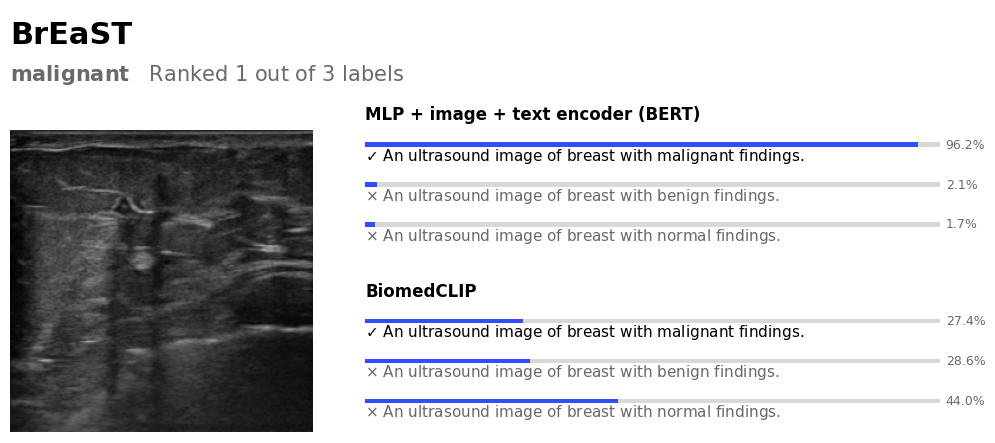

In [12]:
def plot_qualitative_case(
    case,
    label_names,
    label_prompts,
    save_path=None,
    top_k=5,
    display_dataset_name=None,
):
    image_path = case["image_path"]
    true_label = case["true_label"]
    bert_probs = case["bert_probs"]
    biomed_probs = case["biomed_probs"]

    order = np.argsort(-bert_probs)[:top_k]
    sorted_labels = [label_names[i] for i in order]
    sorted_prompts = [label_prompts[i] for i in order]
    bert_sorted = bert_probs[order] * 100
    biomed_sorted = biomed_probs[order] * 100

    dataset_name = (
        display_dataset_name
        if display_dataset_name is not None
        else str(case.get("dataset", FOCUS_DATASET))
    )

    pred_label = case["bert_pred"]
    pred_prob = bert_sorted[0]

    img = Image.open(image_path).convert("RGB")

    fig = plt.figure(figsize=(12, 5.5))
    gs = fig.add_gridspec(
        3, 2,
        width_ratios=[1.0, 1.9],
        height_ratios=[0.55, 1, 1],
        wspace=0.12,
        hspace=0.45,
    )

    # ---- Titles ----
    ax_title = fig.add_subplot(gs[0, :])
    ax_title.axis("off")
    ax_title.text(
        0.0, 0.85,
        dataset_name,
        fontsize=22,
        fontweight="bold",
        ha="left",
        va="top",
    )
    ax_title.text(
        0.0, 0.25,
        rf"$\bf{{{pred_label}}}$   Ranked 1 out of {len(label_names)} labels",
        fontsize=15,
        color="dimgray",
        ha="left",
        va="top",
    )

    # ---- Image ----
    ax_img = fig.add_subplot(gs[1:, 0])
    ax_img.imshow(img, cmap="gray")
    ax_img.axis("off")

    # ---- Ranking panels ----
    def draw_panel(ax, probs, title):
        ax.set_xlim(0, 100)
        ax.set_ylim(-0.4, top_k - 0.2)
        ax.invert_yaxis()
        ax.axis("off")

        ax.text(
            0, -0.75, title,
            fontsize=12,
            fontweight="bold",
            ha="left",
            va="center",
        )

        for i, (prob, lab, prompt) in enumerate(zip(probs, sorted_labels, sorted_prompts)):
            is_true = lab == true_label
            mark = r"$\checkmark$" if is_true else r"$\times$"
            mark_color = "black" if is_true else "dimgray"

            ax.barh(i, 100, height=0.11, color="#d8d8d8", edgecolor="none")
            ax.barh(i, prob, height=0.11, color="#334CFF", edgecolor="none")

            ax.text(
                0, i + 0.28,
                f"{mark} {prompt}",
                fontsize=11,
                color=mark_color,
                ha="left",
                va="center",
            )

            ax.text(
                101, i,
                f"{prob:.1f}%",
                fontsize=9,
                color="dimgray",
                ha="left",
                va="center",
            )

    ax_bert = fig.add_subplot(gs[1, 1])
    draw_panel(ax_bert, bert_sorted, BERT_MODEL_NAME)

    ax_bio = fig.add_subplot(gs[2, 1])
    draw_panel(ax_bio, biomed_sorted, "BiomedCLIP")

    if save_path is not None:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print("Saved figure:", save_path)

    plt.show()


if len(good_cases) > 0:
    selected_idx = int(good_cases.iloc[0]["idx"])
else:
    selected_idx = int(cand_df.sort_values("gap", ascending=False).iloc[0]["idx"])

selected_case = cases[selected_idx]

results_dir = Path("/kaggle/working/qualitative_bert_vs_biomedclip")
results_dir.mkdir(parents=True, exist_ok=True)

plot_qualitative_case(
    selected_case,
    label_names,
    label_prompts,
    save_path=results_dir / "qualitative_case_openai_style.png",
    top_k=min(5, len(label_names)),
    display_dataset_name="BrEaST",  # manually set title here
)

In [13]:
print('Available labeled datasets:')
for x in sorted(labeled_test_df['dataset'].dropna().unique()):
    print(' ', x)

# Change this line to focus on another dataset.
FOCUS_DATASET = 'BUS-Lesion'

subset_df = labeled_test_df[labeled_test_df['dataset'].astype(str) == FOCUS_DATASET].reset_index(drop=True)
print('Focus dataset:', FOCUS_DATASET)
print('Subset size:', len(subset_df))
if len(subset_df) > 0:
    print(subset_df['label'].value_counts())
else:
    print('No rows found. Change FOCUS_DATASET to one of the printed dataset names.')

label_names = sorted(subset_df['label'].dropna().astype(str).str.lower().unique().tolist())
label_prompts = [build_label_prompt_for_dataset(label, FOCUS_DATASET) for label in label_names]
print('Labels:', label_names)
print('Prompts:')
for lab, pr in zip(label_names, label_prompts):
    print(f'  {lab}: {pr}')

if len(label_names) < 2:
    print('Warning: this subset has fewer than two labels, so qualitative classification is not meaningful.')

Available labeled datasets:
  BUS-Lesion
  BrEaST-Lesions_USG-images_and_masks
  Liver USData (with Chinese annotation)
  Lung_ultrasound
  Thyroid
  Thyroid USData (with Chinese annotation)
Focus dataset: BUS-Lesion
Subset size: 775
label
benign       421
malignant    354
Name: count, dtype: int64
Labels: ['benign', 'malignant']
Prompts:
  benign: An ultrasound image of breast with benign findings.
  malignant: An ultrasound image of breast with malignant findings.


In [14]:
# -----------------------------
# Probability functions
# -----------------------------
@torch.no_grad()
def bert_label_probs(model, image_path, label_prompts):
    img = Image.open(image_path).convert('RGB')
    x = trained_img_transform(img).unsqueeze(0).to(device)
    ids, mask = tokenize_texts(label_prompts, tokenizer, max_length=config['max_seq_len'], device=device)

    img_emb = model.encode_image(x)
    txt_emb = model.encode_text(ids, mask)
    scale = torch.clamp(1.0 / model.log_temperature.exp(), max=100.0)
    logits = scale * (img_emb @ txt_emb.T)
    probs = torch.softmax(logits.squeeze(0), dim=0).detach().cpu().numpy()
    return probs

@torch.no_grad()
def biomedclip_label_probs(model, preprocess, tokenizer, image_path, label_prompts):
    img = Image.open(image_path).convert('RGB')
    x = preprocess(img).unsqueeze(0).to(device)
    text_tokens = tokenizer(label_prompts, context_length=256).to(device)

    img_emb = F.normalize(model.encode_image(x), dim=-1)
    txt_emb = F.normalize(model.encode_text(text_tokens), dim=-1)

    if hasattr(model, 'logit_scale'):
        scale = torch.clamp(model.logit_scale.exp(), max=100.0)
    else:
        scale = 1.0
    logits = scale * (img_emb @ txt_emb.T)
    probs = torch.softmax(logits.squeeze(0), dim=0).detach().cpu().numpy()
    return probs

In [15]:
# -----------------------------
# Find examples where BERT UltraCLIP beats BiomedCLIP
# -----------------------------
if len(subset_df) == 0 or len(label_names) < 2:
    raise ValueError('Choose a focus dataset with at least two labeled classes.')

cases = []
for i, row in tqdm(subset_df.iterrows(), total=len(subset_df), desc='Scoring examples'):
    image_path = row['image_path']
    true_label = str(row['label']).lower()

    bert_probs = bert_label_probs(bert_model, image_path, label_prompts)
    biomed_probs = biomedclip_label_probs(
        biomedclip_model,
        biomedclip_preprocess,
        biomedclip_tokenizer,
        image_path,
        label_prompts,
    )

    bert_pred = label_names[int(np.argmax(bert_probs))]
    biomed_pred = label_names[int(np.argmax(biomed_probs))]
    true_idx = label_names.index(true_label) if true_label in label_names else None

    if true_idx is None:
        continue

    cases.append({
        'idx': i,
        'image_path': image_path,
        'image_name': Path(image_path).name,
        'dataset': row['dataset'],
        'true_label': true_label,
        'bert_pred': bert_pred,
        'biomed_pred': biomed_pred,
        'bert_true_prob': float(bert_probs[true_idx]),
        'biomed_true_prob': float(biomed_probs[true_idx]),
        'gap': float(bert_probs[true_idx] - biomed_probs[true_idx]),
        'bert_correct': bert_pred == true_label,
        'biomed_correct': biomed_pred == true_label,
        'bert_probs': bert_probs,
        'biomed_probs': biomed_probs,
    })

cand_df = pd.DataFrame([{k: v for k, v in c.items() if k not in ['bert_probs', 'biomed_probs']} for c in cases])

# Preferred qualitative cases: BERT correct, BiomedCLIP wrong.
good_cases = cand_df[(cand_df['bert_correct']) & (~cand_df['biomed_correct'])].sort_values('gap', ascending=False)

print('Total scored cases:', len(cand_df))
print('BERT correct / Biomed wrong:', len(good_cases))

if len(good_cases) > 0:
    display(good_cases.head(10))
else:
    print('No BERT-correct/Biomed-wrong cases found. Showing largest confidence-gap cases instead.')
    display(cand_df.sort_values('gap', ascending=False).head(10))

Scoring examples:   0%|          | 0/775 [00:00<?, ?it/s]

Total scored cases: 775
BERT correct / Biomed wrong: 147


,idx,image_path,image_name,dataset,true_label,bert_pred,biomed_pred,bert_true_prob,biomed_true_prob,gap,bert_correct,biomed_correct
138,138,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,007825@0.png,BUS-Lesion,malignant,malignant,benign,0.958719,0.052427,0.906292,True,False
341,341,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,007377@0.png,BUS-Lesion,malignant,malignant,benign,0.992226,0.087129,0.905097,True,False
682,682,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,006200@0.png,BUS-Lesion,malignant,malignant,benign,0.969787,0.086540,0.883247,True,False
560,560,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,005907@0.png,BUS-Lesion,malignant,malignant,benign,0.992603,0.113430,0.879173,True,False
333,333,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,007820@0.png,BUS-Lesion,malignant,malignant,benign,0.969294,0.103959,0.865335,True,False
756,756,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,008666@0.png,BUS-Lesion,benign,benign,malignant,0.966385,0.105578,0.860807,True,False
567,567,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,007548@0.png,BUS-Lesion,benign,benign,malignant,0.986733,0.140063,0.846670,True,False
391,391,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,007817@0.png,BUS-Lesion,malignant,malignant,benign,0.989981,0.145383,0.844598,True,False
486,486,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,008793@0.png,BUS-Lesion,benign,benign,malignant,0.991474,0.162518,0.828956,True,False
461,461,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,006107@1.png,BUS-Lesion,malignant,malignant,benign,0.939790,0.111670,0.828120,True,False


Saved figure: /kaggle/working/qualitative_bert_vs_biomedclip/qualitative_case_openai_style.png


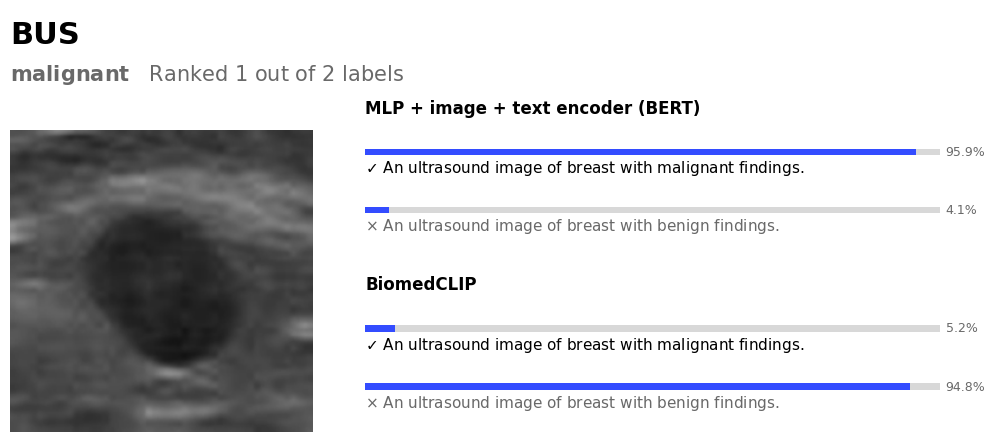

In [18]:
def plot_qualitative_case(
    case,
    label_names,
    label_prompts,
    save_path=None,
    top_k=5,
    display_dataset_name=None,
):
    image_path = case["image_path"]
    true_label = case["true_label"]
    bert_probs = case["bert_probs"]
    biomed_probs = case["biomed_probs"]

    order = np.argsort(-bert_probs)[:top_k]
    sorted_labels = [label_names[i] for i in order]
    sorted_prompts = [label_prompts[i] for i in order]
    bert_sorted = bert_probs[order] * 100
    biomed_sorted = biomed_probs[order] * 100

    dataset_name = (
        display_dataset_name
        if display_dataset_name is not None
        else str(case.get("dataset", FOCUS_DATASET))
    )

    pred_label = case["bert_pred"]
    pred_prob = bert_sorted[0]

    img = Image.open(image_path).convert("RGB")

    fig = plt.figure(figsize=(12, 5.5))
    gs = fig.add_gridspec(
        3, 2,
        width_ratios=[1.0, 1.9],
        height_ratios=[0.55, 1, 1],
        wspace=0.12,
        hspace=0.45,
    )

    # ---- Titles ----
    ax_title = fig.add_subplot(gs[0, :])
    ax_title.axis("off")
    ax_title.text(
        0.0, 0.85,
        dataset_name,
        fontsize=22,
        fontweight="bold",
        ha="left",
        va="top",
    )
    ax_title.text(
        0.0, 0.25,
        rf"$\bf{{{pred_label}}}$   Ranked 1 out of {len(label_names)} labels",
        fontsize=15,
        color="dimgray",
        ha="left",
        va="top",
    )

    # ---- Image ----
    ax_img = fig.add_subplot(gs[1:, 0])
    ax_img.imshow(img, cmap="gray")
    ax_img.axis("off")

    # ---- Ranking panels ----
    def draw_panel(ax, probs, title):
        ax.set_xlim(0, 100)
        ax.set_ylim(-0.4, top_k - 0.2)
        ax.invert_yaxis()
        ax.axis("off")

        ax.text(
            0, -0.75, title,
            fontsize=12,
            fontweight="bold",
            ha="left",
            va="center",
        )

        for i, (prob, lab, prompt) in enumerate(zip(probs, sorted_labels, sorted_prompts)):
            is_true = lab == true_label
            mark = r"$\checkmark$" if is_true else r"$\times$"
            mark_color = "black" if is_true else "dimgray"

            ax.barh(i, 100, height=0.11, color="#d8d8d8", edgecolor="none")
            ax.barh(i, prob, height=0.11, color="#334CFF", edgecolor="none")

            ax.text(
                0, i + 0.28,
                f"{mark} {prompt}",
                fontsize=11,
                color=mark_color,
                ha="left",
                va="center",
            )

            ax.text(
                101, i,
                f"{prob:.1f}%",
                fontsize=9,
                color="dimgray",
                ha="left",
                va="center",
            )

    ax_bert = fig.add_subplot(gs[1, 1])
    draw_panel(ax_bert, bert_sorted, BERT_MODEL_NAME)

    ax_bio = fig.add_subplot(gs[2, 1])
    draw_panel(ax_bio, biomed_sorted, "BiomedCLIP")

    if save_path is not None:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print("Saved figure:", save_path)

    plt.show()


if len(good_cases) > 0:
    selected_idx = int(good_cases.iloc[0]["idx"])
else:
    selected_idx = int(cand_df.sort_values("gap", ascending=False).iloc[0]["idx"])

selected_case = cases[selected_idx]

results_dir = Path("/kaggle/working/qualitative_bert_vs_biomedclip")
results_dir.mkdir(parents=True, exist_ok=True)

plot_qualitative_case(
    selected_case,
    label_names,
    label_prompts,
    save_path=results_dir / "qualitative_case_openai_style.png",
    top_k=min(5, len(label_names)),
    display_dataset_name="BUS",  # manually set title here
)

In [19]:
print('Available labeled datasets:')
for x in sorted(labeled_test_df['dataset'].dropna().unique()):
    print(' ', x)

# Change this line to focus on another dataset.
FOCUS_DATASET = 'Liver USData (with Chinese annotation)'

subset_df = labeled_test_df[labeled_test_df['dataset'].astype(str) == FOCUS_DATASET].reset_index(drop=True)
print('Focus dataset:', FOCUS_DATASET)
print('Subset size:', len(subset_df))
if len(subset_df) > 0:
    print(subset_df['label'].value_counts())
else:
    print('No rows found. Change FOCUS_DATASET to one of the printed dataset names.')

label_names = sorted(subset_df['label'].dropna().astype(str).str.lower().unique().tolist())
label_prompts = [build_label_prompt_for_dataset(label, FOCUS_DATASET) for label in label_names]
print('Labels:', label_names)
print('Prompts:')
for lab, pr in zip(label_names, label_prompts):
    print(f'  {lab}: {pr}')

if len(label_names) < 2:
    print('Warning: this subset has fewer than two labels, so qualitative classification is not meaningful.')

Available labeled datasets:
  BUS-Lesion
  BrEaST-Lesions_USG-images_and_masks
  Liver USData (with Chinese annotation)
  Lung_ultrasound
  Thyroid
  Thyroid USData (with Chinese annotation)
Focus dataset: Liver USData (with Chinese annotation)
Subset size: 75
label
normal    75
Name: count, dtype: int64
Labels: ['normal']
Prompts:
  normal: An ultrasound image of liver with normal findings.


In [20]:
# -----------------------------
# Probability functions
# -----------------------------
@torch.no_grad()
def bert_label_probs(model, image_path, label_prompts):
    img = Image.open(image_path).convert('RGB')
    x = trained_img_transform(img).unsqueeze(0).to(device)
    ids, mask = tokenize_texts(label_prompts, tokenizer, max_length=config['max_seq_len'], device=device)

    img_emb = model.encode_image(x)
    txt_emb = model.encode_text(ids, mask)
    scale = torch.clamp(1.0 / model.log_temperature.exp(), max=100.0)
    logits = scale * (img_emb @ txt_emb.T)
    probs = torch.softmax(logits.squeeze(0), dim=0).detach().cpu().numpy()
    return probs

@torch.no_grad()
def biomedclip_label_probs(model, preprocess, tokenizer, image_path, label_prompts):
    img = Image.open(image_path).convert('RGB')
    x = preprocess(img).unsqueeze(0).to(device)
    text_tokens = tokenizer(label_prompts, context_length=256).to(device)

    img_emb = F.normalize(model.encode_image(x), dim=-1)
    txt_emb = F.normalize(model.encode_text(text_tokens), dim=-1)

    if hasattr(model, 'logit_scale'):
        scale = torch.clamp(model.logit_scale.exp(), max=100.0)
    else:
        scale = 1.0
    logits = scale * (img_emb @ txt_emb.T)
    probs = torch.softmax(logits.squeeze(0), dim=0).detach().cpu().numpy()
    return probs

In [21]:
# -----------------------------
# Find examples where BERT UltraCLIP beats BiomedCLIP
# -----------------------------
if len(subset_df) == 0 or len(label_names) < 2:
    raise ValueError('Choose a focus dataset with at least two labeled classes.')

cases = []
for i, row in tqdm(subset_df.iterrows(), total=len(subset_df), desc='Scoring examples'):
    image_path = row['image_path']
    true_label = str(row['label']).lower()

    bert_probs = bert_label_probs(bert_model, image_path, label_prompts)
    biomed_probs = biomedclip_label_probs(
        biomedclip_model,
        biomedclip_preprocess,
        biomedclip_tokenizer,
        image_path,
        label_prompts,
    )

    bert_pred = label_names[int(np.argmax(bert_probs))]
    biomed_pred = label_names[int(np.argmax(biomed_probs))]
    true_idx = label_names.index(true_label) if true_label in label_names else None

    if true_idx is None:
        continue

    cases.append({
        'idx': i,
        'image_path': image_path,
        'image_name': Path(image_path).name,
        'dataset': row['dataset'],
        'true_label': true_label,
        'bert_pred': bert_pred,
        'biomed_pred': biomed_pred,
        'bert_true_prob': float(bert_probs[true_idx]),
        'biomed_true_prob': float(biomed_probs[true_idx]),
        'gap': float(bert_probs[true_idx] - biomed_probs[true_idx]),
        'bert_correct': bert_pred == true_label,
        'biomed_correct': biomed_pred == true_label,
        'bert_probs': bert_probs,
        'biomed_probs': biomed_probs,
    })

cand_df = pd.DataFrame([{k: v for k, v in c.items() if k not in ['bert_probs', 'biomed_probs']} for c in cases])

# Preferred qualitative cases: BERT correct, BiomedCLIP wrong.
good_cases = cand_df[(cand_df['bert_correct']) & (~cand_df['biomed_correct'])].sort_values('gap', ascending=False)

print('Total scored cases:', len(cand_df))
print('BERT correct / Biomed wrong:', len(good_cases))

if len(good_cases) > 0:
    display(good_cases.head(10))
else:
    print('No BERT-correct/Biomed-wrong cases found. Showing largest confidence-gap cases instead.')
    display(cand_df.sort_values('gap', ascending=False).head(10))

ValueError: Choose a focus dataset with at least two labeled classes.

In [ ]:
def plot_qualitative_case(
    case,
    label_names,
    label_prompts,
    save_path=None,
    top_k=5,
    display_dataset_name=None,
):
    image_path = case["image_path"]
    true_label = case["true_label"]
    bert_probs = case["bert_probs"]
    biomed_probs = case["biomed_probs"]

    order = np.argsort(-bert_probs)[:top_k]
    sorted_labels = [label_names[i] for i in order]
    sorted_prompts = [label_prompts[i] for i in order]
    bert_sorted = bert_probs[order] * 100
    biomed_sorted = biomed_probs[order] * 100

    dataset_name = (
        display_dataset_name
        if display_dataset_name is not None
        else str(case.get("dataset", FOCUS_DATASET))
    )
        rf"$\bf{{{pred_label}}}$     Ranked 1 out of {len(label_names)} labels",

    pred_label = case["bert_pred"]
    pred_prob = bert_sorted[0]

    img = Image.open(image_path).convert("RGB")

    fig = plt.figure(figsize=(12, 5.5))
    gs = fig.add_gridspec(
        3, 2,
        width_ratios=[1.0, 1.9],
        height_ratios=[0.55, 1, 1],
        wspace=0.12,
        hspace=0.45,
    )

    # ---- Titles ----
    ax_title = fig.add_subplot(gs[0, :])
    ax_title.axis("off")
    ax_title.text(
        0.0, 0.85,
        dataset_name,
        fontsize=22,
        fontweight="bold",
        ha="left",
        va="top",
    )
    ax_title.text(
        0.0, 0.25,
        rf"$\bf{{{pred_label}}}$     Ranked 1 out of {len(label_names)} labels",
        fontsize=15,
        color="dimgray",
        ha="left",
        va="top",
    )

    # ---- Image ----
    ax_img = fig.add_subplot(gs[1:, 0])
    ax_img.imshow(img, cmap="gray")
    ax_img.axis("off")

    # ---- Ranking panels ----
    def draw_panel(ax, probs, title):
        ax.set_xlim(0, 100)
        ax.set_ylim(-0.4, top_k - 0.2)
        ax.invert_yaxis()
        ax.axis("off")

        ax.text(
            0, -0.75, title,
            fontsize=12,
            fontweight="bold",
            ha="left",
            va="center",
        )

        for i, (prob, lab, prompt) in enumerate(zip(probs, sorted_labels, sorted_prompts)):
            is_true = lab == true_label
            mark = r"$\checkmark$" if is_true else r"$\times$"
            mark_color = "black" if is_true else "dimgray"

            ax.barh(i, 100, height=0.11, color="#d8d8d8", edgecolor="none")
            ax.barh(i, prob, height=0.11, color="#334CFF", edgecolor="none")

            ax.text(
                0, i + 0.28,
                f"{mark} {prompt}",
                fontsize=11,
                color=mark_color,
                ha="left",
                va="center",
            )

            ax.text(
            ax.text(
                101, i,
                f"{prob:.1f}%",
                fontsize=9,
                color="dimgray",
                ha="left",
                va="center",
            )

    ax_bert = fig.add_subplot(gs[1, 1])
    draw_panel(ax_bert, bert_sorted, BERT_MODEL_NAME)

    ax_bio = fig.add_subplot(gs[2, 1])
    draw_panel(ax_bio, biomed_sorted, "BiomedCLIP")

    if save_path is not None:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print("Saved figure:", save_path)

    plt.show()


if len(good_cases) > 0:
    selected_idx = int(good_cases.iloc[0]["idx"])
else:
    selected_idx = int(cand_df.sort_values("gap", ascending=False).iloc[0]["idx"])

selected_case = cases[selected_idx]

results_dir = Path("/kaggle/working/qualitative_bert_vs_biomedclip")
results_dir.mkdir(parents=True, exist_ok=True)

plot_qualitative_case(
    selected_case,
    label_names,
    label_prompts,
    save_path=results_dir / "qualitative_case_openai_style.png",
    top_k=min(5, len(label_names)),
    display_dataset_name="Liver USData",  # manually set title here
)

In [26]:
print('Available labeled datasets:')
for x in sorted(labeled_test_df['dataset'].dropna().unique()):
    print(' ', x)

# Change this line to focus on another dataset.
FOCUS_DATASET = 'Lung_ultrasound'

subset_df = labeled_test_df[labeled_test_df['dataset'].astype(str) == FOCUS_DATASET].reset_index(drop=True)
print('Focus dataset:', FOCUS_DATASET)
print('Subset size:', len(subset_df))
if len(subset_df) > 0:
    print(subset_df['label'].value_counts())
else:
    print('No rows found. Change FOCUS_DATASET to one of the printed dataset names.')

label_names = sorted(subset_df['label'].dropna().astype(str).str.lower().unique().tolist())
label_prompts = [build_label_prompt_for_dataset(label, FOCUS_DATASET) for label in label_names]
print('Labels:', label_names)
print('Prompts:')
for lab, pr in zip(label_names, label_prompts):
    print(f'  {lab}: {pr}')

if len(label_names) < 2:
    print('Warning: this subset has fewer than two labels, so qualitative classification is not meaningful.')

Available labeled datasets:
  BUS-Lesion
  BrEaST-Lesions_USG-images_and_masks
  Liver USData (with Chinese annotation)
  Lung_ultrasound
  Thyroid
  Thyroid USData (with Chinese annotation)
Focus dataset: Lung_ultrasound
Subset size: 159
label
healthy    55
other      55
covid      49
Name: count, dtype: int64
Labels: ['covid', 'healthy', 'other']
Prompts:
  covid: An ultrasound image of lung with covid findings.
  healthy: An ultrasound image of lung with healthy findings.
  other: An ultrasound image of lung with other findings.


In [27]:
# -----------------------------
# Probability functions
# -----------------------------
@torch.no_grad()
def bert_label_probs(model, image_path, label_prompts):
    img = Image.open(image_path).convert('RGB')
    x = trained_img_transform(img).unsqueeze(0).to(device)
    ids, mask = tokenize_texts(label_prompts, tokenizer, max_length=config['max_seq_len'], device=device)

    img_emb = model.encode_image(x)
    txt_emb = model.encode_text(ids, mask)
    scale = torch.clamp(1.0 / model.log_temperature.exp(), max=100.0)
    logits = scale * (img_emb @ txt_emb.T)
    probs = torch.softmax(logits.squeeze(0), dim=0).detach().cpu().numpy()
    return probs

@torch.no_grad()
def biomedclip_label_probs(model, preprocess, tokenizer, image_path, label_prompts):
    img = Image.open(image_path).convert('RGB')
    x = preprocess(img).unsqueeze(0).to(device)
    text_tokens = tokenizer(label_prompts, context_length=256).to(device)

    img_emb = F.normalize(model.encode_image(x), dim=-1)
    txt_emb = F.normalize(model.encode_text(text_tokens), dim=-1)

    if hasattr(model, 'logit_scale'):
        scale = torch.clamp(model.logit_scale.exp(), max=100.0)
    else:
        scale = 1.0
    logits = scale * (img_emb @ txt_emb.T)
    probs = torch.softmax(logits.squeeze(0), dim=0).detach().cpu().numpy()
    return probs

In [28]:
# -----------------------------
# Find examples where BERT UltraCLIP beats BiomedCLIP
# -----------------------------
if len(subset_df) == 0 or len(label_names) < 2:
    raise ValueError('Choose a focus dataset with at least two labeled classes.')

cases = []
for i, row in tqdm(subset_df.iterrows(), total=len(subset_df), desc='Scoring examples'):
    image_path = row['image_path']
    true_label = str(row['label']).lower()

    bert_probs = bert_label_probs(bert_model, image_path, label_prompts)
    biomed_probs = biomedclip_label_probs(
        biomedclip_model,
        biomedclip_preprocess,
        biomedclip_tokenizer,
        image_path,
        label_prompts,
    )

    bert_pred = label_names[int(np.argmax(bert_probs))]
    biomed_pred = label_names[int(np.argmax(biomed_probs))]
    true_idx = label_names.index(true_label) if true_label in label_names else None

    if true_idx is None:
        continue

    cases.append({
        'idx': i,
        'image_path': image_path,
        'image_name': Path(image_path).name,
        'dataset': row['dataset'],
        'true_label': true_label,
        'bert_pred': bert_pred,
        'biomed_pred': biomed_pred,
        'bert_true_prob': float(bert_probs[true_idx]),
        'biomed_true_prob': float(biomed_probs[true_idx]),
        'gap': float(bert_probs[true_idx] - biomed_probs[true_idx]),
        'bert_correct': bert_pred == true_label,
        'biomed_correct': biomed_pred == true_label,
        'bert_probs': bert_probs,
        'biomed_probs': biomed_probs,
    })

cand_df = pd.DataFrame([{k: v for k, v in c.items() if k not in ['bert_probs', 'biomed_probs']} for c in cases])

# Preferred qualitative cases: BERT correct, BiomedCLIP wrong.
good_cases = cand_df[(cand_df['bert_correct']) & (~cand_df['biomed_correct'])].sort_values('gap', ascending=False)

print('Total scored cases:', len(cand_df))
print('BERT correct / Biomed wrong:', len(good_cases))

if len(good_cases) > 0:
    display(good_cases.head(10))
else:
    print('No BERT-correct/Biomed-wrong cases found. Showing largest confidence-gap cases instead.')
    display(cand_df.sort_values('gap', ascending=False).head(10))

Scoring examples:   0%|          | 0/159 [00:00<?, ?it/s]

Total scored cases: 159
BERT correct / Biomed wrong: 35


,idx,image_path,image_name,dataset,true_label,bert_pred,biomed_pred,bert_true_prob,biomed_true_prob,gap,bert_correct,biomed_correct
12,12,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,lung_covid_115.png,Lung_ultrasound,covid,covid,healthy,0.878552,0.089523,0.789030,True,False
15,15,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,lung_covid_255.png,Lung_ultrasound,covid,covid,healthy,0.797593,0.144632,0.652961,True,False
143,143,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,lung_healthy_213.png,Lung_ultrasound,healthy,healthy,covid,0.721851,0.102741,0.619110,True,False
153,153,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,lung_healthy_130.png,Lung_ultrasound,healthy,healthy,covid,0.749808,0.143171,0.606637,True,False
46,46,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,lung_covid_214.png,Lung_ultrasound,covid,covid,healthy,0.938838,0.340197,0.598641,True,False
25,25,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,lung_healthy_95.png,Lung_ultrasound,healthy,healthy,covid,0.732633,0.150554,0.582079,True,False
86,86,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,lung_covid_60.png,Lung_ultrasound,covid,covid,healthy,0.993411,0.413507,0.579903,True,False
79,79,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,lung_covid_267.png,Lung_ultrasound,covid,covid,healthy,0.749522,0.214841,0.534681,True,False
117,117,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,lung_covid_216.png,Lung_ultrasound,covid,covid,healthy,0.805700,0.271304,0.534396,True,False
1,1,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,lung_covid_16.png,Lung_ultrasound,covid,covid,healthy,0.736338,0.208082,0.528256,True,False


Saved figure: /kaggle/working/qualitative_bert_vs_biomedclip/qualitative_case_openai_style.png


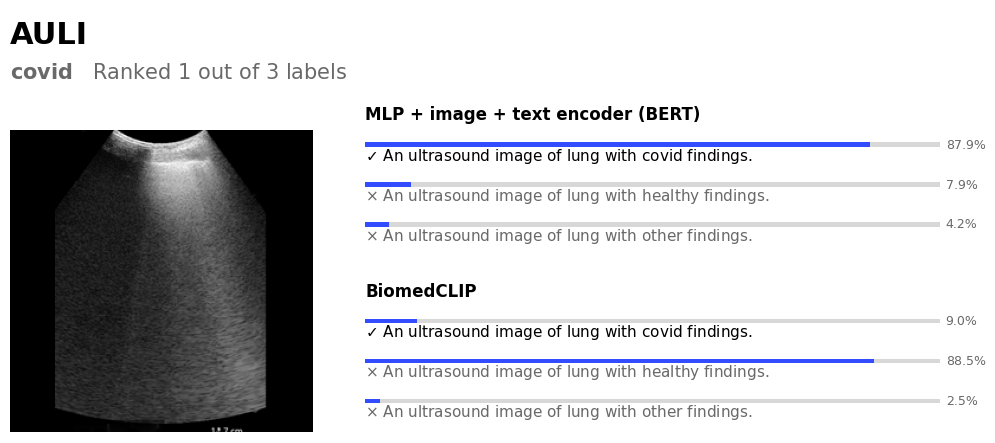

In [29]:
def plot_qualitative_case(
    case,
    label_names,
    label_prompts,
    save_path=None,
    top_k=5,
    display_dataset_name=None,
):
    image_path = case["image_path"]
    true_label = case["true_label"]
    bert_probs = case["bert_probs"]
    biomed_probs = case["biomed_probs"]

    order = np.argsort(-bert_probs)[:top_k]
    sorted_labels = [label_names[i] for i in order]
    sorted_prompts = [label_prompts[i] for i in order]
    bert_sorted = bert_probs[order] * 100
    biomed_sorted = biomed_probs[order] * 100

    dataset_name = (
        display_dataset_name
        if display_dataset_name is not None
        else str(case.get("dataset", FOCUS_DATASET))
    )

    pred_label = case["bert_pred"]
    pred_prob = bert_sorted[0]

    img = Image.open(image_path).convert("RGB")

    fig = plt.figure(figsize=(12, 5.5))
    gs = fig.add_gridspec(
        3, 2,
        width_ratios=[1.0, 1.9],
        height_ratios=[0.55, 1, 1],
        wspace=0.12,
        hspace=0.45,
    )

    # ---- Titles ----
    ax_title = fig.add_subplot(gs[0, :])
    ax_title.axis("off")
    ax_title.text(
        0.0, 0.85,
        dataset_name,
        fontsize=22,
        fontweight="bold",
        ha="left",
        va="top",
    )
    ax_title.text(
        0.0, 0.25,
        rf"$\bf{{{pred_label}}}$   Ranked 1 out of {len(label_names)} labels",
        fontsize=15,
        color="dimgray",
        ha="left",
        va="top",
    )

    # ---- Image ----
    ax_img = fig.add_subplot(gs[1:, 0])
    ax_img.imshow(img, cmap="gray")
    ax_img.axis("off")

    # ---- Ranking panels ----
    def draw_panel(ax, probs, title):
        ax.set_xlim(0, 100)
        ax.set_ylim(-0.4, top_k - 0.2)
        ax.invert_yaxis()
        ax.axis("off")

        ax.text(
            0, -0.75, title,
            fontsize=12,
            fontweight="bold",
            ha="left",
            va="center",
        )

        for i, (prob, lab, prompt) in enumerate(zip(probs, sorted_labels, sorted_prompts)):
            is_true = lab == true_label
            mark = r"$\checkmark$" if is_true else r"$\times$"
            mark_color = "black" if is_true else "dimgray"

            ax.barh(i, 100, height=0.11, color="#d8d8d8", edgecolor="none")
            ax.barh(i, prob, height=0.11, color="#334CFF", edgecolor="none")

            ax.text(
                0, i + 0.28,
                f"{mark} {prompt}",
                fontsize=11,
                color=mark_color,
                ha="left",
                va="center",
            )

            ax.text(
                101, i,
                f"{prob:.1f}%",
                fontsize=9,
                color="dimgray",
                ha="left",
                va="center",
            )

    ax_bert = fig.add_subplot(gs[1, 1])
    draw_panel(ax_bert, bert_sorted, BERT_MODEL_NAME)

    ax_bio = fig.add_subplot(gs[2, 1])
    draw_panel(ax_bio, biomed_sorted, "BiomedCLIP")

    if save_path is not None:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print("Saved figure:", save_path)

    plt.show()


if len(good_cases) > 0:
    selected_idx = int(good_cases.iloc[0]["idx"])
else:
    selected_idx = int(cand_df.sort_values("gap", ascending=False).iloc[0]["idx"])

selected_case = cases[selected_idx]

results_dir = Path("/kaggle/working/qualitative_bert_vs_biomedclip")
results_dir.mkdir(parents=True, exist_ok=True)

plot_qualitative_case(
    selected_case,
    label_names,
    label_prompts,
    save_path=results_dir / "qualitative_case_openai_style.png",
    top_k=min(5, len(label_names)),
    display_dataset_name="AULI",  # manually set title here
)

In [22]:
print('Available labeled datasets:')
for x in sorted(labeled_test_df['dataset'].dropna().unique()):
    print(' ', x)

# Change this line to focus on another dataset.
FOCUS_DATASET = 'Thyroid'

subset_df = labeled_test_df[labeled_test_df['dataset'].astype(str) == FOCUS_DATASET].reset_index(drop=True)
print('Focus dataset:', FOCUS_DATASET)
print('Subset size:', len(subset_df))
if len(subset_df) > 0:
    print(subset_df['label'].value_counts())
else:
    print('No rows found. Change FOCUS_DATASET to one of the printed dataset names.')

label_names = sorted(subset_df['label'].dropna().astype(str).str.lower().unique().tolist())
label_prompts = [build_label_prompt_for_dataset(label, FOCUS_DATASET) for label in label_names]
print('Labels:', label_names)
print('Prompts:')
for lab, pr in zip(label_names, label_prompts):
    print(f'  {lab}: {pr}')

if len(label_names) < 2:
    print('Warning: this subset has fewer than two labels, so qualitative classification is not meaningful.')

Available labeled datasets:
  BUS-Lesion
  BrEaST-Lesions_USG-images_and_masks
  Liver USData (with Chinese annotation)
  Lung_ultrasound
  Thyroid
  Thyroid USData (with Chinese annotation)
Focus dataset: Thyroid
Subset size: 344
label
malignant    241
benign        89
normal        14
Name: count, dtype: int64
Labels: ['benign', 'malignant', 'normal']
Prompts:
  benign: An ultrasound image of thyroid with benign findings.
  malignant: An ultrasound image of thyroid with malignant findings.
  normal: An ultrasound image of thyroid with normal findings.


In [23]:
# -----------------------------
# Probability functions
# -----------------------------
@torch.no_grad()
def bert_label_probs(model, image_path, label_prompts):
    img = Image.open(image_path).convert('RGB')
    x = trained_img_transform(img).unsqueeze(0).to(device)
    ids, mask = tokenize_texts(label_prompts, tokenizer, max_length=config['max_seq_len'], device=device)

    img_emb = model.encode_image(x)
    txt_emb = model.encode_text(ids, mask)
    scale = torch.clamp(1.0 / model.log_temperature.exp(), max=100.0)
    logits = scale * (img_emb @ txt_emb.T)
    probs = torch.softmax(logits.squeeze(0), dim=0).detach().cpu().numpy()
    return probs

@torch.no_grad()
def biomedclip_label_probs(model, preprocess, tokenizer, image_path, label_prompts):
    img = Image.open(image_path).convert('RGB')
    x = preprocess(img).unsqueeze(0).to(device)
    text_tokens = tokenizer(label_prompts, context_length=256).to(device)

    img_emb = F.normalize(model.encode_image(x), dim=-1)
    txt_emb = F.normalize(model.encode_text(text_tokens), dim=-1)

    if hasattr(model, 'logit_scale'):
        scale = torch.clamp(model.logit_scale.exp(), max=100.0)
    else:
        scale = 1.0
    logits = scale * (img_emb @ txt_emb.T)
    probs = torch.softmax(logits.squeeze(0), dim=0).detach().cpu().numpy()
    return probs

In [24]:
# -----------------------------
# Find examples where BERT UltraCLIP beats BiomedCLIP
# -----------------------------
if len(subset_df) == 0 or len(label_names) < 2:
    raise ValueError('Choose a focus dataset with at least two labeled classes.')

cases = []
for i, row in tqdm(subset_df.iterrows(), total=len(subset_df), desc='Scoring examples'):
    image_path = row['image_path']
    true_label = str(row['label']).lower()

    bert_probs = bert_label_probs(bert_model, image_path, label_prompts)
    biomed_probs = biomedclip_label_probs(
        biomedclip_model,
        biomedclip_preprocess,
        biomedclip_tokenizer,
        image_path,
        label_prompts,
    )

    bert_pred = label_names[int(np.argmax(bert_probs))]
    biomed_pred = label_names[int(np.argmax(biomed_probs))]
    true_idx = label_names.index(true_label) if true_label in label_names else None

    if true_idx is None:
        continue

    cases.append({
        'idx': i,
        'image_path': image_path,
        'image_name': Path(image_path).name,
        'dataset': row['dataset'],
        'true_label': true_label,
        'bert_pred': bert_pred,
        'biomed_pred': biomed_pred,
        'bert_true_prob': float(bert_probs[true_idx]),
        'biomed_true_prob': float(biomed_probs[true_idx]),
        'gap': float(bert_probs[true_idx] - biomed_probs[true_idx]),
        'bert_correct': bert_pred == true_label,
        'biomed_correct': biomed_pred == true_label,
        'bert_probs': bert_probs,
        'biomed_probs': biomed_probs,
    })

cand_df = pd.DataFrame([{k: v for k, v in c.items() if k not in ['bert_probs', 'biomed_probs']} for c in cases])

# Preferred qualitative cases: BERT correct, BiomedCLIP wrong.
good_cases = cand_df[(cand_df['bert_correct']) & (~cand_df['biomed_correct'])].sort_values('gap', ascending=False)

print('Total scored cases:', len(cand_df))
print('BERT correct / Biomed wrong:', len(good_cases))

if len(good_cases) > 0:
    display(good_cases.head(10))
else:
    print('No BERT-correct/Biomed-wrong cases found. Showing largest confidence-gap cases instead.')
    display(cand_df.sort_values('gap', ascending=False).head(10))

Scoring examples:   0%|          | 0/344 [00:00<?, ?it/s]

Total scored cases: 344
BERT correct / Biomed wrong: 88


,idx,image_path,image_name,dataset,true_label,bert_pred,biomed_pred,bert_true_prob,biomed_true_prob,gap,bert_correct,biomed_correct
332,332,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,tiroides100.png,Thyroid,malignant,malignant,normal,0.780494,0.023616,0.756878,True,False
123,123,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,4B_35.png,Thyroid,malignant,malignant,benign,0.887023,0.140208,0.746815,True,False
84,84,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,4C_36.png,Thyroid,malignant,malignant,benign,0.925833,0.222772,0.703061,True,False
160,160,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,4A_69.png,Thyroid,malignant,malignant,normal,0.677200,0.041191,0.636008,True,False
260,260,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,tiroides222.png,Thyroid,malignant,malignant,normal,0.672921,0.088311,0.584610,True,False
296,296,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,4A_28.png,Thyroid,malignant,malignant,normal,0.782254,0.213809,0.568444,True,False
141,141,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,4C_21.png,Thyroid,malignant,malignant,normal,0.680479,0.142310,0.538169,True,False
113,113,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,4C_29.png,Thyroid,malignant,malignant,benign,0.739338,0.217671,0.521667,True,False
225,225,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,4B_25.png,Thyroid,malignant,malignant,normal,0.713033,0.200680,0.512353,True,False
38,38,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,4C_31.png,Thyroid,malignant,malignant,normal,0.647511,0.139212,0.508299,True,False


Saved figure: /kaggle/working/qualitative_bert_vs_biomedclip/qualitative_case_openai_style.png


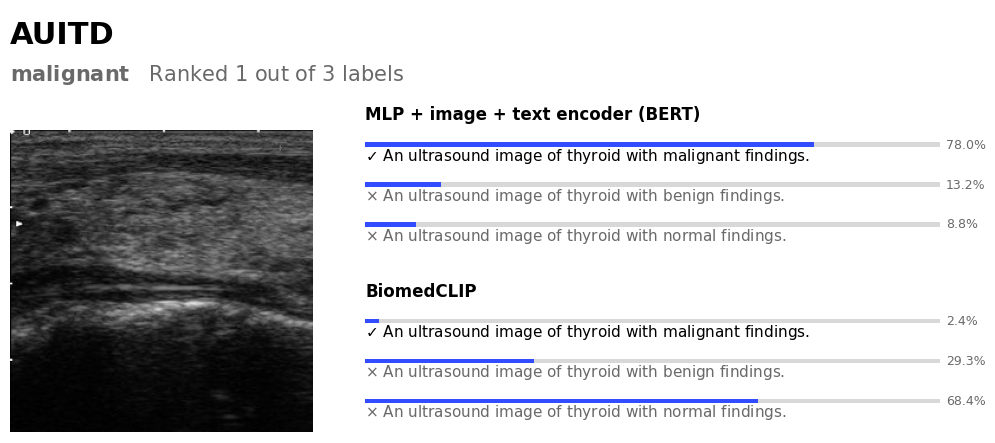

In [25]:
def plot_qualitative_case(
    case,
    label_names,
    label_prompts,
    save_path=None,
    top_k=5,
    display_dataset_name=None,
):
    image_path = case["image_path"]
    true_label = case["true_label"]
    bert_probs = case["bert_probs"]
    biomed_probs = case["biomed_probs"]

    order = np.argsort(-bert_probs)[:top_k]
    sorted_labels = [label_names[i] for i in order]
    sorted_prompts = [label_prompts[i] for i in order]
    bert_sorted = bert_probs[order] * 100
    biomed_sorted = biomed_probs[order] * 100

    dataset_name = (
        display_dataset_name
        if display_dataset_name is not None
        else str(case.get("dataset", FOCUS_DATASET))
    )

    pred_label = case["bert_pred"]
    pred_prob = bert_sorted[0]

    img = Image.open(image_path).convert("RGB")

    fig = plt.figure(figsize=(12, 5.5))
    gs = fig.add_gridspec(
        3, 2,
        width_ratios=[1.0, 1.9],
        height_ratios=[0.55, 1, 1],
        wspace=0.12,
        hspace=0.45,
    )

    # ---- Titles ----
    ax_title = fig.add_subplot(gs[0, :])
    ax_title.axis("off")
    ax_title.text(
        0.0, 0.85,
        dataset_name,
        fontsize=22,
        fontweight="bold",
        ha="left",
        va="top",
    )
    ax_title.text(
        0.0, 0.25,
        rf"$\bf{{{pred_label}}}$   Ranked 1 out of {len(label_names)} labels",
        fontsize=15,
        color="dimgray",
        ha="left",
        va="top",
    )

    # ---- Image ----
    ax_img = fig.add_subplot(gs[1:, 0])
    ax_img.imshow(img, cmap="gray")
    ax_img.axis("off")

    # ---- Ranking panels ----
    def draw_panel(ax, probs, title):
        ax.set_xlim(0, 100)
        ax.set_ylim(-0.4, top_k - 0.2)
        ax.invert_yaxis()
        ax.axis("off")

        ax.text(
            0, -0.75, title,
            fontsize=12,
            fontweight="bold",
            ha="left",
            va="center",
        )

        for i, (prob, lab, prompt) in enumerate(zip(probs, sorted_labels, sorted_prompts)):
            is_true = lab == true_label
            mark = r"$\checkmark$" if is_true else r"$\times$"
            mark_color = "black" if is_true else "dimgray"

            ax.barh(i, 100, height=0.11, color="#d8d8d8", edgecolor="none")
            ax.barh(i, prob, height=0.11, color="#334CFF", edgecolor="none")

            ax.text(
                0, i + 0.28,
                f"{mark} {prompt}",
                fontsize=11,
                color=mark_color,
                ha="left",
                va="center",
            )

            ax.text(
                101, i,
                f"{prob:.1f}%",
                fontsize=9,
                color="dimgray",
                ha="left",
                va="center",
            )

    ax_bert = fig.add_subplot(gs[1, 1])
    draw_panel(ax_bert, bert_sorted, BERT_MODEL_NAME)

    ax_bio = fig.add_subplot(gs[2, 1])
    draw_panel(ax_bio, biomed_sorted, "BiomedCLIP")

    if save_path is not None:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print("Saved figure:", save_path)

    plt.show()


if len(good_cases) > 0:
    selected_idx = int(good_cases.iloc[0]["idx"])
else:
    selected_idx = int(cand_df.sort_values("gap", ascending=False).iloc[0]["idx"])

selected_case = cases[selected_idx]

results_dir = Path("/kaggle/working/qualitative_bert_vs_biomedclip")
results_dir.mkdir(parents=True, exist_ok=True)

plot_qualitative_case(
    selected_case,
    label_names,
    label_prompts,
    save_path=results_dir / "qualitative_case_openai_style.png",
    top_k=min(5, len(label_names)),
    display_dataset_name="AUITD",  # manually set title here
)

In [ ]:
print('Available labeled datasets:')
for x in sorted(labeled_test_df['dataset'].dropna().unique()):
    print(' ', x)

# Change this line to focus on another dataset.
FOCUS_DATASET = 'Thyroid USData (with Chinese annotation)'

subset_df = labeled_test_df[labeled_test_df['dataset'].astype(str) == FOCUS_DATASET].reset_index(drop=True)
print('Focus dataset:', FOCUS_DATASET)
print('Subset size:', len(subset_df))
if len(subset_df) > 0:
    print(subset_df['label'].value_counts())
else:
    print('No rows found. Change FOCUS_DATASET to one of the printed dataset names.')

label_names = sorted(subset_df['label'].dropna().astype(str).str.lower().unique().tolist())
label_prompts = [build_label_prompt_for_dataset(label, FOCUS_DATASET) for label in label_names]
print('Labels:', label_names)
print('Prompts:')
for lab, pr in zip(label_names, label_prompts):
    print(f'  {lab}: {pr}')

if len(label_names) < 2:
    print('Warning: this subset has fewer than two labels, so qualitative classification is not meaningful.')

In [ ]:
# -----------------------------
# Probability functions
# -----------------------------
@torch.no_grad()
def bert_label_probs(model, image_path, label_prompts):
    img = Image.open(image_path).convert('RGB')
    x = trained_img_transform(img).unsqueeze(0).to(device)
    ids, mask = tokenize_texts(label_prompts, tokenizer, max_length=config['max_seq_len'], device=device)

    img_emb = model.encode_image(x)
    txt_emb = model.encode_text(ids, mask)
    scale = torch.clamp(1.0 / model.log_temperature.exp(), max=100.0)
    logits = scale * (img_emb @ txt_emb.T)
    probs = torch.softmax(logits.squeeze(0), dim=0).detach().cpu().numpy()
    return probs

@torch.no_grad()
def biomedclip_label_probs(model, preprocess, tokenizer, image_path, label_prompts):
    img = Image.open(image_path).convert('RGB')
    x = preprocess(img).unsqueeze(0).to(device)
    text_tokens = tokenizer(label_prompts, context_length=256).to(device)

    img_emb = F.normalize(model.encode_image(x), dim=-1)
    txt_emb = F.normalize(model.encode_text(text_tokens), dim=-1)

    if hasattr(model, 'logit_scale'):
        scale = torch.clamp(model.logit_scale.exp(), max=100.0)
    else:
        scale = 1.0
    logits = scale * (img_emb @ txt_emb.T)
    probs = torch.softmax(logits.squeeze(0), dim=0).detach().cpu().numpy()
    return probs

In [ ]:
# -----------------------------
# Find examples where BERT UltraCLIP beats BiomedCLIP
# -----------------------------
if len(subset_df) == 0 or len(label_names) < 2:
    raise ValueError('Choose a focus dataset with at least two labeled classes.')

cases = []
for i, row in tqdm(subset_df.iterrows(), total=len(subset_df), desc='Scoring examples'):
    image_path = row['image_path']
    true_label = str(row['label']).lower()

    bert_probs = bert_label_probs(bert_model, image_path, label_prompts)
    biomed_probs = biomedclip_label_probs(
        biomedclip_model,
        biomedclip_preprocess,
        biomedclip_tokenizer,
        image_path,
        label_prompts,
    )

    bert_pred = label_names[int(np.argmax(bert_probs))]
    biomed_pred = label_names[int(np.argmax(biomed_probs))]
    true_idx = label_names.index(true_label) if true_label in label_names else None

    if true_idx is None:
        continue

    cases.append({
        'idx': i,
        'image_path': image_path,
        'image_name': Path(image_path).name,
        'dataset': row['dataset'],
        'true_label': true_label,
        'bert_pred': bert_pred,
        'biomed_pred': biomed_pred,
        'bert_true_prob': float(bert_probs[true_idx]),
        'biomed_true_prob': float(biomed_probs[true_idx]),
        'gap': float(bert_probs[true_idx] - biomed_probs[true_idx]),
        'bert_correct': bert_pred == true_label,
        'biomed_correct': biomed_pred == true_label,
        'bert_probs': bert_probs,
        'biomed_probs': biomed_probs,
    })

cand_df = pd.DataFrame([{k: v for k, v in c.items() if k not in ['bert_probs', 'biomed_probs']} for c in cases])

# Preferred qualitative cases: BERT correct, BiomedCLIP wrong.
good_cases = cand_df[(cand_df['bert_correct']) & (~cand_df['biomed_correct'])].sort_values('gap', ascending=False)

print('Total scored cases:', len(cand_df))
print('BERT correct / Biomed wrong:', len(good_cases))

if len(good_cases) > 0:
    display(good_cases.head(10))
else:
    print('No BERT-correct/Biomed-wrong cases found. Showing largest confidence-gap cases instead.')
    display(cand_df.sort_values('gap', ascending=False).head(10))

In [ ]:
def plot_qualitative_case(
    case,
    label_names,
    label_prompts,
    save_path=None,
    top_k=5,
    display_dataset_name=None,
):
    image_path = case["image_path"]
    true_label = case["true_label"]
    bert_probs = case["bert_probs"]
    biomed_probs = case["biomed_probs"]

    order = np.argsort(-bert_probs)[:top_k]
    sorted_labels = [label_names[i] for i in order]
    sorted_prompts = [label_prompts[i] for i in order]
    bert_sorted = bert_probs[order] * 100
    biomed_sorted = biomed_probs[order] * 100

    dataset_name = (
        display_dataset_name
        if display_dataset_name is not None
        else str(case.get("dataset", FOCUS_DATASET))
    )
        rf"$\bf{{{pred_label}}}$     Ranked 1 out of {len(label_names)} labels",

    pred_label = case["bert_pred"]
    pred_prob = bert_sorted[0]

    img = Image.open(image_path).convert("RGB")

    fig = plt.figure(figsize=(12, 5.5))
    gs = fig.add_gridspec(
        3, 2,
        width_ratios=[1.0, 1.9],
        height_ratios=[0.55, 1, 1],
        wspace=0.12,
        hspace=0.45,
    )

    # ---- Titles ----
    ax_title = fig.add_subplot(gs[0, :])
    ax_title.axis("off")
    ax_title.text(
        0.0, 0.85,
        dataset_name,
        fontsize=22,
        fontweight="bold",
        ha="left",
        va="top",
    )
    ax_title.text(
        0.0, 0.25,
        rf"$\bf{{{pred_label}}}$     Ranked 1 out of {len(label_names)} labels",
        fontsize=15,
        color="dimgray",
        ha="left",
        va="top",
    )

    # ---- Image ----
    ax_img = fig.add_subplot(gs[1:, 0])
    ax_img.imshow(img, cmap="gray")
    ax_img.axis("off")

    # ---- Ranking panels ----
    def draw_panel(ax, probs, title):
        ax.set_xlim(0, 100)
        ax.set_ylim(-0.4, top_k - 0.2)
        ax.invert_yaxis()
        ax.axis("off")

        ax.text(
            0, -0.75, title,
            fontsize=12,
            fontweight="bold",
            ha="left",
            va="center",
        )

        for i, (prob, lab, prompt) in enumerate(zip(probs, sorted_labels, sorted_prompts)):
            is_true = lab == true_label
            mark = r"$\checkmark$" if is_true else r"$\times$"
            mark_color = "black" if is_true else "dimgray"

            ax.barh(i, 100, height=0.11, color="#d8d8d8", edgecolor="none")
            ax.barh(i, prob, height=0.11, color="#334CFF", edgecolor="none")

            ax.text(
                0, i + 0.28,
                f"{mark} {prompt}",
                fontsize=11,
                color=mark_color,
                ha="left",
                va="center",
            )

            ax.text(
            ax.text(
                101, i,
                f"{prob:.1f}%",
                fontsize=9,
                color="dimgray",
                ha="left",
                va="center",
            )

    ax_bert = fig.add_subplot(gs[1, 1])
    draw_panel(ax_bert, bert_sorted, BERT_MODEL_NAME)

    ax_bio = fig.add_subplot(gs[2, 1])
    draw_panel(ax_bio, biomed_sorted, "BiomedCLIP")

    if save_path is not None:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print("Saved figure:", save_path)

    plt.show()


if len(good_cases) > 0:
    selected_idx = int(good_cases.iloc[0]["idx"])
else:
    selected_idx = int(cand_df.sort_values("gap", ascending=False).iloc[0]["idx"])

selected_case = cases[selected_idx]

results_dir = Path("/kaggle/working/qualitative_bert_vs_biomedclip")
results_dir.mkdir(parents=True, exist_ok=True)

plot_qualitative_case(
    selected_case,
    label_names,
    label_prompts,
    save_path=results_dir / "qualitative_case_openai_style.png",
    top_k=min(5, len(label_names)),
    display_dataset_name="Thyroid USData",  # manually set title here
)

In [33]:
from pathlib import Path
import pandas as pd

# ===============================
# Custom dataset config
# ===============================
CUSTOM_DATASET_NAME = "BUSI"
CUSTOM_IMAGE_ROOT = Path("/kaggle/input/datasets/yiyangzhangyoung/bmi702-preprocessed/Dataset_BUSI_with_GT/Dataset_BUSI_with_GT")
CUSTOM_CSV = Path("/kaggle/input/datasets/yiyangzhangyoung/bmi702-preprocessed/Dataset_BUSI_with_GT/Dataset_BUSI_with_GT/all_captions.csv")

CUSTOM_IMAGE_ROOT = Path(
    "/kaggle/input/datasets/yiyangzhangyoung/bmi702-preprocessed/Dataset_BUSI_with_GT/Dataset_BUSI_with_GT"
)

def resolve_image_path(x):
    x = Path(str(x))
    if x.is_absolute():
        return str(x)
    return str(CUSTOM_IMAGE_ROOT / x)

# ===============================
# Load custom CSV
# ===============================
custom_df = pd.read_csv(CUSTOM_CSV)
custom_df.columns = [c.strip() for c in custom_df.columns]

def find_col(columns, candidates):
    cols_lower = {c.lower(): c for c in columns}
    for cand in candidates:
        for low, orig in cols_lower.items():
            if cand in low:
                return orig
    return None

image_col = find_col(custom_df.columns, ["image_path", "image", "filename", "file_name", "path"])
label_col = find_col(custom_df.columns, ["label", "class", "diagnosis", "condition"])
caption_col = find_col(custom_df.columns, ["caption", "text_caption", "annotation", "text"])

if image_col is None:
    raise ValueError(f"Could not find image column. Available columns: {list(custom_df.columns)}")

if label_col is None:
    raise ValueError(f"Could not find label column. Available columns: {list(custom_df.columns)}")

if caption_col is None:
    print("No caption column found. Using empty caption.")
    custom_df["caption"] = ""
    caption_col = "caption"

# def resolve_image_path(x):
#     x = Path(str(x))
#     if x.is_absolute() and x.exists():
#         return str(x)
#     return str(CUSTOM_IMAGE_ROOT / x.name)

subset_df = pd.DataFrame({
    "image_path": custom_df[image_col].apply(resolve_image_path),
    "caption": custom_df[caption_col].astype(str),
    "label": custom_df[label_col].astype(str).str.strip().str.lower(),
    "dataset": CUSTOM_DATASET_NAME,
})

subset_df["exists"] = subset_df["image_path"].apply(lambda p: Path(p).exists())
missing = subset_df[~subset_df["exists"]]

print("Loaded rows:", len(subset_df))
print("Existing images:", subset_df["exists"].sum())
print("Missing images:", len(missing))

if len(missing) > 0:
    print("Example missing paths:")
    display(missing.head())

subset_df = subset_df[subset_df["exists"]].drop(columns=["exists"]).reset_index(drop=True)

label_names = sorted(subset_df["label"].dropna().unique().tolist())
label_prompts = [build_label_prompt_for_dataset(label, CUSTOM_DATASET_NAME) for label in label_names]

print("\nFinal custom subset size:", len(subset_df))
print("\nLabel counts:")
print(subset_df["label"].value_counts())

print("\nLabels and prompts:")
for lab, pr in zip(label_names, label_prompts):
    print(f"{lab}: {pr}")

Loaded rows: 780
Existing images: 780
Missing images: 0

Final custom subset size: 780

Label counts:
label
benign       437
malignant    210
normal       133
Name: count, dtype: int64

Labels and prompts:
benign: An ultrasound image of breast with benign findings.
malignant: An ultrasound image of breast with malignant findings.
normal: An ultrasound image of breast with normal findings.


In [34]:
# -----------------------------
# Probability functions
# -----------------------------
@torch.no_grad()
def bert_label_probs(model, image_path, label_prompts):
    img = Image.open(image_path).convert('RGB')
    x = trained_img_transform(img).unsqueeze(0).to(device)
    ids, mask = tokenize_texts(label_prompts, tokenizer, max_length=config['max_seq_len'], device=device)

    img_emb = model.encode_image(x)
    txt_emb = model.encode_text(ids, mask)
    scale = torch.clamp(1.0 / model.log_temperature.exp(), max=100.0)
    logits = scale * (img_emb @ txt_emb.T)
    probs = torch.softmax(logits.squeeze(0), dim=0).detach().cpu().numpy()
    return probs

@torch.no_grad()
def biomedclip_label_probs(model, preprocess, tokenizer, image_path, label_prompts):
    img = Image.open(image_path).convert('RGB')
    x = preprocess(img).unsqueeze(0).to(device)
    text_tokens = tokenizer(label_prompts, context_length=256).to(device)

    img_emb = F.normalize(model.encode_image(x), dim=-1)
    txt_emb = F.normalize(model.encode_text(text_tokens), dim=-1)

    if hasattr(model, 'logit_scale'):
        scale = torch.clamp(model.logit_scale.exp(), max=100.0)
    else:
        scale = 1.0
    logits = scale * (img_emb @ txt_emb.T)
    probs = torch.softmax(logits.squeeze(0), dim=0).detach().cpu().numpy()
    return probs

In [35]:
# -----------------------------
# Find examples where BERT UltraCLIP beats BiomedCLIP
# -----------------------------
if len(subset_df) == 0 or len(label_names) < 2:
    raise ValueError('Choose a focus dataset with at least two labeled classes.')

cases = []
for i, row in tqdm(subset_df.iterrows(), total=len(subset_df), desc='Scoring examples'):
    image_path = row['image_path']
    true_label = str(row['label']).lower()

    bert_probs = bert_label_probs(bert_model, image_path, label_prompts)
    biomed_probs = biomedclip_label_probs(
        biomedclip_model,
        biomedclip_preprocess,
        biomedclip_tokenizer,
        image_path,
        label_prompts,
    )

    bert_pred = label_names[int(np.argmax(bert_probs))]
    biomed_pred = label_names[int(np.argmax(biomed_probs))]
    true_idx = label_names.index(true_label) if true_label in label_names else None

    if true_idx is None:
        continue

    cases.append({
        'idx': i,
        'image_path': image_path,
        'image_name': Path(image_path).name,
        'dataset': row['dataset'],
        'true_label': true_label,
        'bert_pred': bert_pred,
        'biomed_pred': biomed_pred,
        'bert_true_prob': float(bert_probs[true_idx]),
        'biomed_true_prob': float(biomed_probs[true_idx]),
        'gap': float(bert_probs[true_idx] - biomed_probs[true_idx]),
        'bert_correct': bert_pred == true_label,
        'biomed_correct': biomed_pred == true_label,
        'bert_probs': bert_probs,
        'biomed_probs': biomed_probs,
    })

cand_df = pd.DataFrame([{k: v for k, v in c.items() if k not in ['bert_probs', 'biomed_probs']} for c in cases])

# Preferred qualitative cases: BERT correct, BiomedCLIP wrong.
good_cases = cand_df[(cand_df['bert_correct']) & (~cand_df['biomed_correct'])].sort_values('gap', ascending=False)

print('Total scored cases:', len(cand_df))
print('BERT correct / Biomed wrong:', len(good_cases))

if len(good_cases) > 0:
    display(good_cases.head(10))
else:
    print('No BERT-correct/Biomed-wrong cases found. Showing largest confidence-gap cases instead.')
    display(cand_df.sort_values('gap', ascending=False).head(10))

Scoring examples:   0%|          | 0/780 [00:00<?, ?it/s]

Total scored cases: 780
BERT correct / Biomed wrong: 69


,idx,image_path,image_name,dataset,true_label,bert_pred,biomed_pred,bert_true_prob,biomed_true_prob,gap,bert_correct,biomed_correct
560,560,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,malignant (21).png,BUSI,malignant,malignant,normal,0.970466,0.139419,0.831047,True,False
626,626,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,malignant (80).png,BUSI,malignant,malignant,normal,0.801146,0.020223,0.780923,True,False
550,550,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,malignant (200).png,BUSI,malignant,malignant,normal,0.911381,0.160407,0.750974,True,False
540,540,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,malignant (192).png,BUSI,malignant,malignant,normal,0.969699,0.253038,0.716661,True,False
471,471,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,malignant (13).png,BUSI,malignant,malignant,normal,0.952043,0.258634,0.693410,True,False
448,448,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,malignant (109).png,BUSI,malignant,malignant,normal,0.945135,0.264372,0.680763,True,False
573,573,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,malignant (32).png,BUSI,malignant,malignant,normal,0.935202,0.270142,0.665060,True,False
453,453,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,malignant (113).png,BUSI,malignant,malignant,normal,0.880288,0.266181,0.614107,True,False
444,444,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,malignant (105).png,BUSI,malignant,malignant,normal,0.696535,0.100044,0.596491,True,False
477,477,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,malignant (135).png,BUSI,malignant,malignant,normal,0.786526,0.215477,0.571049,True,False


Saved figure: /kaggle/working/qualitative_bert_vs_biomedclip/qualitative_case_openai_style.png


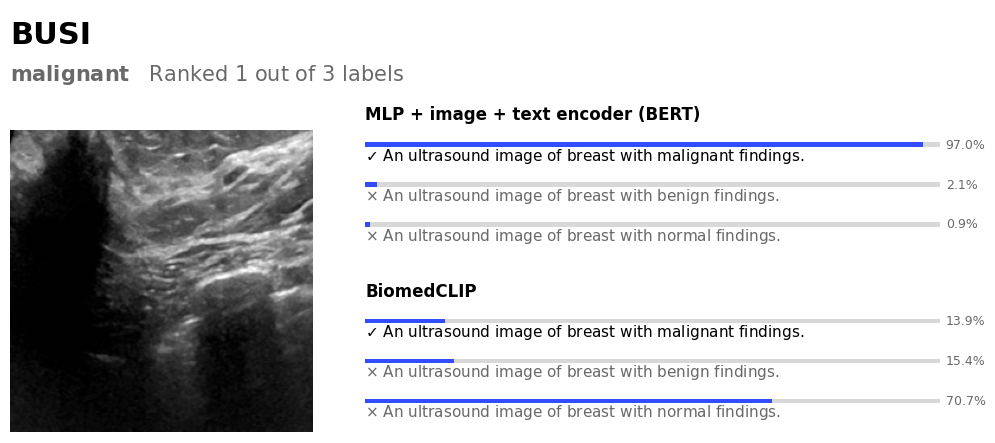

In [36]:
def plot_qualitative_case(
    case,
    label_names,
    label_prompts,
    save_path=None,
    top_k=5,
    display_dataset_name=None,
):
    image_path = case["image_path"]
    true_label = case["true_label"]
    bert_probs = case["bert_probs"]
    biomed_probs = case["biomed_probs"]

    order = np.argsort(-bert_probs)[:top_k]
    sorted_labels = [label_names[i] for i in order]
    sorted_prompts = [label_prompts[i] for i in order]
    bert_sorted = bert_probs[order] * 100
    biomed_sorted = biomed_probs[order] * 100

    dataset_name = (
        display_dataset_name
        if display_dataset_name is not None
        else str(case.get("dataset", FOCUS_DATASET))
    )

    pred_label = case["bert_pred"]
    pred_prob = bert_sorted[0]

    img = Image.open(image_path).convert("RGB")

    fig = plt.figure(figsize=(12, 5.5))
    gs = fig.add_gridspec(
        3, 2,
        width_ratios=[1.0, 1.9],
        height_ratios=[0.55, 1, 1],
        wspace=0.12,
        hspace=0.45,
    )

    # ---- Titles ----
    ax_title = fig.add_subplot(gs[0, :])
    ax_title.axis("off")
    ax_title.text(
        0.0, 0.85,
        dataset_name,
        fontsize=22,
        fontweight="bold",
        ha="left",
        va="top",
    )
    ax_title.text(
        0.0, 0.25,
        rf"$\bf{{{pred_label}}}$   Ranked 1 out of {len(label_names)} labels",
        fontsize=15,
        color="dimgray",
        ha="left",
        va="top",
    )

    # ---- Image ----
    ax_img = fig.add_subplot(gs[1:, 0])
    ax_img.imshow(img, cmap="gray")
    ax_img.axis("off")

    # ---- Ranking panels ----
    def draw_panel(ax, probs, title):
        ax.set_xlim(0, 100)
        ax.set_ylim(-0.4, top_k - 0.2)
        ax.invert_yaxis()
        ax.axis("off")

        ax.text(
            0, -0.75, title,
            fontsize=12,
            fontweight="bold",
            ha="left",
            va="center",
        )

        for i, (prob, lab, prompt) in enumerate(zip(probs, sorted_labels, sorted_prompts)):
            is_true = lab == true_label
            mark = r"$\checkmark$" if is_true else r"$\times$"
            mark_color = "black" if is_true else "dimgray"

            ax.barh(i, 100, height=0.11, color="#d8d8d8", edgecolor="none")
            ax.barh(i, prob, height=0.11, color="#334CFF", edgecolor="none")

            ax.text(
                0, i + 0.28,
                f"{mark} {prompt}",
                fontsize=11,
                color=mark_color,
                ha="left",
                va="center",
            )

            ax.text(
                101, i,
                f"{prob:.1f}%",
                fontsize=9,
                color="dimgray",
                ha="left",
                va="center",
            )

    ax_bert = fig.add_subplot(gs[1, 1])
    draw_panel(ax_bert, bert_sorted, BERT_MODEL_NAME)

    ax_bio = fig.add_subplot(gs[2, 1])
    draw_panel(ax_bio, biomed_sorted, "BiomedCLIP")

    if save_path is not None:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print("Saved figure:", save_path)

    plt.show()


if len(good_cases) > 0:
    selected_idx = int(good_cases.iloc[0]["idx"])
else:
    selected_idx = int(cand_df.sort_values("gap", ascending=False).iloc[0]["idx"])

selected_case = cases[selected_idx]

results_dir = Path("/kaggle/working/qualitative_bert_vs_biomedclip")
results_dir.mkdir(parents=True, exist_ok=True)

plot_qualitative_case(
    selected_case,
    label_names,
    label_prompts,
    save_path=results_dir / "qualitative_case_openai_style.png",
    top_k=min(5, len(label_names)),
    display_dataset_name="BUSI",  # manually set title here
)

In [37]:
from pathlib import Path
import pandas as pd

# ===============================
# Custom dataset config
# ===============================
CUSTOM_DATASET_NAME = "AULI"
CUSTOM_IMAGE_ROOT = Path("/kaggle/input/datasets/yiyangzhangyoung/bmi702-preprocessed/Liver_ultrasound/Liver_ultrasound/AULI_resized_images")
CUSTOM_CSV = Path("/kaggle/input/datasets/yiyangzhangyoung/bmi702-preprocessed/Liver_ultrasound/Liver_ultrasound/AULI_resized_images/captions.csv")

def resolve_image_path(x):
    x = Path(str(x))
    if x.is_absolute():
        return str(x)
    return str(CUSTOM_IMAGE_ROOT / x)

# ===============================
# Load custom CSV
# ===============================
custom_df = pd.read_csv(CUSTOM_CSV)
custom_df.columns = [c.strip() for c in custom_df.columns]

def find_col(columns, candidates):
    cols_lower = {c.lower(): c for c in columns}
    for cand in candidates:
        for low, orig in cols_lower.items():
            if cand in low:
                return orig
    return None

image_col = find_col(custom_df.columns, ["image_path", "image", "filename", "file_name", "path"])
label_col = find_col(custom_df.columns, ["label", "class", "diagnosis", "condition"])
caption_col = find_col(custom_df.columns, ["caption", "text_caption", "annotation", "text"])

if image_col is None:
    raise ValueError(f"Could not find image column. Available columns: {list(custom_df.columns)}")

if label_col is None:
    raise ValueError(f"Could not find label column. Available columns: {list(custom_df.columns)}")

if caption_col is None:
    print("No caption column found. Using empty caption.")
    custom_df["caption"] = ""
    caption_col = "caption"

# def resolve_image_path(x):
#     x = Path(str(x))
#     if x.is_absolute() and x.exists():
#         return str(x)
#     return str(CUSTOM_IMAGE_ROOT / x.name)

subset_df = pd.DataFrame({
    "image_path": custom_df[image_col].apply(resolve_image_path),
    "caption": custom_df[caption_col].astype(str),
    "label": custom_df[label_col].astype(str).str.strip().str.lower(),
    "dataset": CUSTOM_DATASET_NAME,
})

subset_df["exists"] = subset_df["image_path"].apply(lambda p: Path(p).exists())
missing = subset_df[~subset_df["exists"]]

print("Loaded rows:", len(subset_df))
print("Existing images:", subset_df["exists"].sum())
print("Missing images:", len(missing))

if len(missing) > 0:
    print("Example missing paths:")
    display(missing.head())

subset_df = subset_df[subset_df["exists"]].drop(columns=["exists"]).reset_index(drop=True)

label_names = sorted(subset_df["label"].dropna().unique().tolist())
label_prompts = [build_label_prompt_for_dataset(label, CUSTOM_DATASET_NAME) for label in label_names]

print("\nFinal custom subset size:", len(subset_df))
print("\nLabel counts:")
print(subset_df["label"].value_counts())

print("\nLabels and prompts:")
for lab, pr in zip(label_names, label_prompts):
    print(f"{lab}: {pr}")

Loaded rows: 735
Existing images: 735
Missing images: 0

Final custom subset size: 735

Label counts:
label
malignant    435
benign       200
normal       100
Name: count, dtype: int64

Labels and prompts:
benign: An ultrasound image of liver with benign findings.
malignant: An ultrasound image of liver with malignant findings.
normal: An ultrasound image of liver with normal findings.


In [38]:
# -----------------------------
# Probability functions
# -----------------------------
@torch.no_grad()
def bert_label_probs(model, image_path, label_prompts):
    img = Image.open(image_path).convert('RGB')
    x = trained_img_transform(img).unsqueeze(0).to(device)
    ids, mask = tokenize_texts(label_prompts, tokenizer, max_length=config['max_seq_len'], device=device)

    img_emb = model.encode_image(x)
    txt_emb = model.encode_text(ids, mask)
    scale = torch.clamp(1.0 / model.log_temperature.exp(), max=100.0)
    logits = scale * (img_emb @ txt_emb.T)
    probs = torch.softmax(logits.squeeze(0), dim=0).detach().cpu().numpy()
    return probs

@torch.no_grad()
def biomedclip_label_probs(model, preprocess, tokenizer, image_path, label_prompts):
    img = Image.open(image_path).convert('RGB')
    x = preprocess(img).unsqueeze(0).to(device)
    text_tokens = tokenizer(label_prompts, context_length=256).to(device)

    img_emb = F.normalize(model.encode_image(x), dim=-1)
    txt_emb = F.normalize(model.encode_text(text_tokens), dim=-1)

    if hasattr(model, 'logit_scale'):
        scale = torch.clamp(model.logit_scale.exp(), max=100.0)
    else:
        scale = 1.0
    logits = scale * (img_emb @ txt_emb.T)
    probs = torch.softmax(logits.squeeze(0), dim=0).detach().cpu().numpy()
    return probs

In [39]:
# -----------------------------
# Find examples where BERT UltraCLIP beats BiomedCLIP
# -----------------------------
if len(subset_df) == 0 or len(label_names) < 2:
    raise ValueError('Choose a focus dataset with at least two labeled classes.')

cases = []
for i, row in tqdm(subset_df.iterrows(), total=len(subset_df), desc='Scoring examples'):
    image_path = row['image_path']
    true_label = str(row['label']).lower()

    bert_probs = bert_label_probs(bert_model, image_path, label_prompts)
    biomed_probs = biomedclip_label_probs(
        biomedclip_model,
        biomedclip_preprocess,
        biomedclip_tokenizer,
        image_path,
        label_prompts,
    )

    bert_pred = label_names[int(np.argmax(bert_probs))]
    biomed_pred = label_names[int(np.argmax(biomed_probs))]
    true_idx = label_names.index(true_label) if true_label in label_names else None

    if true_idx is None:
        continue

    cases.append({
        'idx': i,
        'image_path': image_path,
        'image_name': Path(image_path).name,
        'dataset': row['dataset'],
        'true_label': true_label,
        'bert_pred': bert_pred,
        'biomed_pred': biomed_pred,
        'bert_true_prob': float(bert_probs[true_idx]),
        'biomed_true_prob': float(biomed_probs[true_idx]),
        'gap': float(bert_probs[true_idx] - biomed_probs[true_idx]),
        'bert_correct': bert_pred == true_label,
        'biomed_correct': biomed_pred == true_label,
        'bert_probs': bert_probs,
        'biomed_probs': biomed_probs,
    })

cand_df = pd.DataFrame([{k: v for k, v in c.items() if k not in ['bert_probs', 'biomed_probs']} for c in cases])

# Preferred qualitative cases: BERT correct, BiomedCLIP wrong.
good_cases = cand_df[(cand_df['bert_correct']) & (~cand_df['biomed_correct'])].sort_values('gap', ascending=False)

print('Total scored cases:', len(cand_df))
print('BERT correct / Biomed wrong:', len(good_cases))

if len(good_cases) > 0:
    display(good_cases.head(10))
else:
    print('No BERT-correct/Biomed-wrong cases found. Showing largest confidence-gap cases instead.')
    display(cand_df.sort_values('gap', ascending=False).head(10))

Scoring examples:   0%|          | 0/735 [00:00<?, ?it/s]

Total scored cases: 735
BERT correct / Biomed wrong: 18


,idx,image_path,image_name,dataset,true_label,bert_pred,biomed_pred,bert_true_prob,biomed_true_prob,gap,bert_correct,biomed_correct
85,85,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,liver_benign_176.png,AULI,benign,benign,normal,0.526250,0.052123,0.474128,True,False
104,104,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,liver_benign_193.png,AULI,benign,benign,normal,0.508050,0.039520,0.468529,True,False
100,100,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,liver_benign_19.png,AULI,benign,benign,normal,0.507744,0.068924,0.438821,True,False
93,93,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,liver_benign_183.png,AULI,benign,benign,normal,0.543445,0.122557,0.420888,True,False
122,122,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,liver_benign_29.png,AULI,benign,benign,normal,0.507941,0.102743,0.405198,True,False
67,67,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,liver_benign_16.png,AULI,benign,benign,normal,0.524555,0.133132,0.391423,True,False
107,107,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,liver_benign_196.png,AULI,benign,benign,normal,0.504047,0.119162,0.384884,True,False
123,123,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,liver_benign_3.png,AULI,benign,benign,normal,0.505642,0.143817,0.361825,True,False
14,14,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,liver_benign_111.png,AULI,benign,benign,normal,0.535194,0.186154,0.349041,True,False
639,639,/kaggle/input/datasets/yiyangzhangyoung/bmi702...,liver_normal_12.png,AULI,normal,normal,benign,0.598803,0.260123,0.338680,True,False


Saved figure: /kaggle/working/qualitative_bert_vs_biomedclip/qualitative_case_openai_style.png


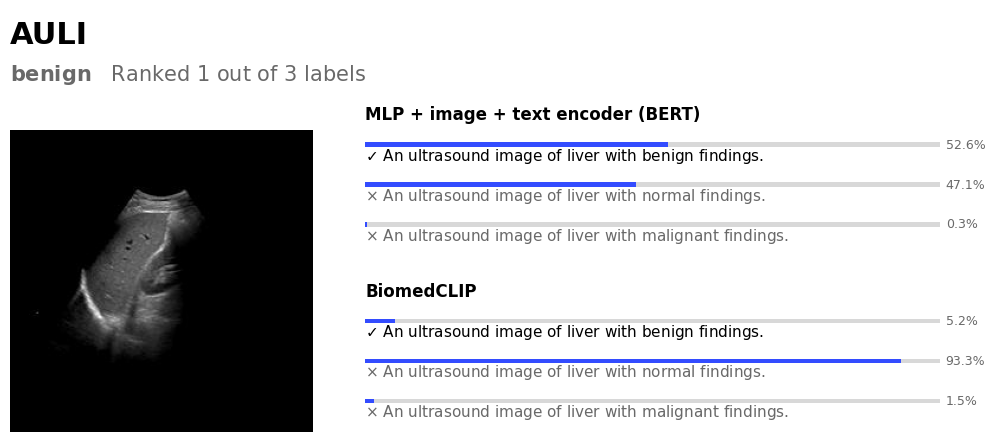

In [40]:
def plot_qualitative_case(
    case,
    label_names,
    label_prompts,
    save_path=None,
    top_k=5,
    display_dataset_name=None,
):
    image_path = case["image_path"]
    true_label = case["true_label"]
    bert_probs = case["bert_probs"]
    biomed_probs = case["biomed_probs"]

    order = np.argsort(-bert_probs)[:top_k]
    sorted_labels = [label_names[i] for i in order]
    sorted_prompts = [label_prompts[i] for i in order]
    bert_sorted = bert_probs[order] * 100
    biomed_sorted = biomed_probs[order] * 100

    dataset_name = (
        display_dataset_name
        if display_dataset_name is not None
        else str(case.get("dataset", FOCUS_DATASET))
    )

    pred_label = case["bert_pred"]
    pred_prob = bert_sorted[0]

    img = Image.open(image_path).convert("RGB")

    fig = plt.figure(figsize=(12, 5.5))
    gs = fig.add_gridspec(
        3, 2,
        width_ratios=[1.0, 1.9],
        height_ratios=[0.55, 1, 1],
        wspace=0.12,
        hspace=0.45,
    )

    # ---- Titles ----
    ax_title = fig.add_subplot(gs[0, :])
    ax_title.axis("off")
    ax_title.text(
        0.0, 0.85,
        dataset_name,
        fontsize=22,
        fontweight="bold",
        ha="left",
        va="top",
    )
    ax_title.text(
        0.0, 0.25,
        rf"$\bf{{{pred_label}}}$   Ranked 1 out of {len(label_names)} labels",
        fontsize=15,
        color="dimgray",
        ha="left",
        va="top",
    )

    # ---- Image ----
    ax_img = fig.add_subplot(gs[1:, 0])
    ax_img.imshow(img, cmap="gray")
    ax_img.axis("off")

    # ---- Ranking panels ----
    def draw_panel(ax, probs, title):
        ax.set_xlim(0, 100)
        ax.set_ylim(-0.4, top_k - 0.2)
        ax.invert_yaxis()
        ax.axis("off")

        ax.text(
            0, -0.75, title,
            fontsize=12,
            fontweight="bold",
            ha="left",
            va="center",
        )

        for i, (prob, lab, prompt) in enumerate(zip(probs, sorted_labels, sorted_prompts)):
            is_true = lab == true_label
            mark = r"$\checkmark$" if is_true else r"$\times$"
            mark_color = "black" if is_true else "dimgray"

            ax.barh(i, 100, height=0.11, color="#d8d8d8", edgecolor="none")
            ax.barh(i, prob, height=0.11, color="#334CFF", edgecolor="none")

            ax.text(
                0, i + 0.28,
                f"{mark} {prompt}",
                fontsize=11,
                color=mark_color,
                ha="left",
                va="center",
            )

            ax.text(
                101, i,
                f"{prob:.1f}%",
                fontsize=9,
                color="dimgray",
                ha="left",
                va="center",
            )

    ax_bert = fig.add_subplot(gs[1, 1])
    draw_panel(ax_bert, bert_sorted, BERT_MODEL_NAME)

    ax_bio = fig.add_subplot(gs[2, 1])
    draw_panel(ax_bio, biomed_sorted, "BiomedCLIP")

    if save_path is not None:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print("Saved figure:", save_path)

    plt.show()


if len(good_cases) > 0:
    selected_idx = int(good_cases.iloc[0]["idx"])
else:
    selected_idx = int(cand_df.sort_values("gap", ascending=False).iloc[0]["idx"])

selected_case = cases[selected_idx]

results_dir = Path("/kaggle/working/qualitative_bert_vs_biomedclip")
results_dir.mkdir(parents=True, exist_ok=True)

plot_qualitative_case(
    selected_case,
    label_names,
    label_prompts,
    save_path=results_dir / "qualitative_case_openai_style.png",
    top_k=min(5, len(label_names)),
    display_dataset_name="AULI",  # manually set title here
)

In [ ]:
# -----------------------------
# Probability table for the selected case
# -----------------------------
prob_table = pd.DataFrame({
    'label': label_names,
    f'{BERT_MODEL_NAME}_prob_percent': selected_case['bert_probs'] * 100,
    'BiomedCLIP_prob_percent': selected_case['biomed_probs'] * 100,
}).sort_values(f'{BERT_MODEL_NAME}_prob_percent', ascending=False).reset_index(drop=True)

print('Selected image:', selected_case['image_name'])
print('Image path:', selected_case['image_path'])
print('Dataset:', selected_case['dataset'])
print('True label:', selected_case['true_label'])
print('BERT prediction:', selected_case['bert_pred'])
print('BiomedCLIP prediction:', selected_case['biomed_pred'])
print('BERT true-label probability:', f"{selected_case['bert_true_prob']*100:.2f}%")
print('BiomedCLIP true-label probability:', f"{selected_case['biomed_true_prob']*100:.2f}%")
print('Gap:', f"{selected_case['gap']*100:.2f} percentage points")

display(prob_table)

# Save outputs
cand_df.to_csv(results_dir / 'candidate_cases.csv', index=False)
prob_table.to_csv(results_dir / 'selected_case_probabilities.csv', index=False)
print('Saved candidate table:', results_dir / 'candidate_cases.csv')
print('Saved probability table:', results_dir / 'selected_case_probabilities.csv')

In [ ]:
# Optional: manually plot another case from the displayed candidate table.
# Set MANUAL_IDX to a value from the cand_df['idx'] column.
MANUAL_IDX = None

if MANUAL_IDX is not None:
    manual_case = cases[int(MANUAL_IDX)]
    plot_qualitative_case(manual_case, label_names, save_path=results_dir / f'qualitative_case_idx_{MANUAL_IDX}.png')